In [52]:
# ============================================================================
# CELL 1: Imports from existing stable modules (unchanged)
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
from astropy.coordinates import SkyCoord
from dustmaps.sfd import SFDQuery
from rubin_sim.maf.slicers import UserPointsSlicer
from rubin_sim.phot_utils import DustValues
import astropy.units as u


repo_root = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric")
sys.path.insert(0, str(repo_root / "py_files"))

# Import from YOUR existing modules (these are NOT modified)

from slsn_metrics.constants import z_from_comoving_fast, dm_from_z
from slsn_metrics.model import LC, CatalogInputs, atomic_save_pickle
from slsn_metrics.metrics import SLSN_Detect_Metric
from slsn_metrics.diagnostics import (
    plot_metrics_mosaic,
    plot_population_diagnostics,
    characterize_template_coverage
)
from slsn_metrics.runners import (
    run_slsn_detect,
    build_filenames,
    get_distance_bounds
)

# Import the ORIGINAL population function (we'll create a new version)
from slsn_metrics.population import (
    inject_uniform_healpix,
    _cached_uniform_healpix,
    _HEALPIX_MEMO
)

print("✓ Imported all stable modules successfully")

✓ Imported all stable modules successfully


In [5]:
# ============================================================================
# CELL 2: Define NEW rate evolution functions (inline, no module changes)
# ============================================================================

import astropy.units as u

# Observed rate measurements from literature (Figure 1 from abstract)
OBSERVED_RATES = [
    {'z': 0.17, 'rate': 1e-7, 'err_low': 0.3e-7, 'err_high': 0.3e-7, 
     'ref': 'Quimby+13'},
    {'z': 0.3, 'rate': 3.5e-7, 'err_low': 1.0e-7, 'err_high': 1.5e-7, 
     'ref': 'Prajs+17'},
    {'z': 2.0, 'rate': 1.5e-6, 'err_low': 0.5e-6, 'err_high': 0.8e-6, 
     'ref': 'Cooke+12'},
]

def cosmic_sfr_density_MD14(z):
    """
    Madau & Dickinson 2014 cosmic SFR density [M_sun/yr/Mpc^3].
    Equation 15 from their paper.
    """
    z = np.atleast_1d(z)
    psi = 0.015 * (1 + z)**2.7 / (1 + ((1 + z) / 2.9)**5.6)
    # FIX: Use .size instead of len()
    return psi.item() if psi.size == 1 else psi


# ============================================================================
# MZR and Galaxy Population Functions (Equation 2 from abstract)
# ============================================================================

def tremonti04_mzr(log_M_star, z=0):
    """
    Tremonti+2004 Mass-Metallicity Relation (their Equation 3).
    
    12 + log(O/H) as a function of stellar mass.
    
    Parameters
    ----------
    log_M_star : float or array
        log10(M_*/M_sun)
    z : float
        Redshift (Tremonti+04 is z~0; for evolution use Andrews & Martini 2013)
    
    Returns
    -------
    OH : float or array
        12 + log10(O/H) [oxygen abundance]
    
    Notes
    -----
    Tremonti+04 Equation 3:
    12 + log(O/H) = -1.492 + 1.847x - 0.08026x²
    where x = log(M_*/M_sun) - 10
    
    For redshift evolution, we apply Andrews & Martini 2013:
    OH(z) = OH(z=0) - 0.14*z  (approximate)
    """
    log_M_star = np.atleast_1d(log_M_star)
    x = log_M_star - 10.0  # Normalized mass
    
    # Tremonti+04 fit (valid for log M_* ~ 8.5 - 11.5)
    OH_z0 = -1.492 + 1.847*x - 0.08026*x**2
    
    # Redshift evolution (Andrews & Martini 2013)
    # Metallicity decreases with lookback time
    OH = OH_z0 - 0.14 * z
    
    return OH.item() if OH.size == 1 else OH


def leja20_stellar_mass_function(log_M_star, z):
    """
    Leja+2020 stellar mass function Φ(M_*|z).
    
    Simplified Schechter function with redshift evolution.
    
    Parameters
    ----------
    log_M_star : float or array
        log10(M_*/M_sun)
    z : float
        Redshift
    
    Returns
    -------
    phi : float or array
        Number density [Mpc^-3 dex^-1]
    
    Notes
    -----
    This is a SIMPLIFIED version. For full Leja+20 model, see their Table 2.
    Using double Schechter function parameters at z~0.5:
    - φ_1* ≈ 10^-2.5 Mpc^-3 dex^-1
    - M_1* ≈ 10^10.7 M_sun
    - α_1 ≈ -0.4
    """
    log_M_star = np.atleast_1d(log_M_star)
    
    # Redshift-dependent parameters (approximate scaling)
    log_phi_star = -2.5 - 0.3 * z  # Normalization decreases with z
    log_M_star_char = 10.7 - 0.1 * z  # Characteristic mass evolves
    alpha = -0.4 - 0.15 * z  # Faint-end slope steepens
    
    phi_star = 10**log_phi_star
    M_star_char = 10**log_M_star_char
    M_star = 10**log_M_star
    
    # Schechter function: φ(M) = φ* (M/M*)^α exp(-M/M*)
    phi = phi_star * (M_star / M_star_char)**alpha * np.exp(-M_star / M_star_char)
    
    # Convert to per dex: Φ(log M) = ln(10) * M * φ(M)
    phi_per_dex = np.log(10) * M_star * phi
    
    return phi_per_dex.item() if phi_per_dex.size == 1 else phi_per_dex


def leja22_mean_sfr(log_M_star, z):
    """
    Leja+2022 mean SFR as function of stellar mass and redshift.
    
    Star-forming main sequence: SFR ∝ M_* × (1+z)^β
    
    Parameters
    ----------
    log_M_star : float or array
        log10(M_*/M_sun)
    z : float
        Redshift
    
    Returns
    -------
    sfr : float or array
        Mean star formation rate [M_sun/yr]
    
    Notes
    -----
    Simplified main sequence relation:
    log(SFR) = α + β*log(M_*) + γ*log(1+z)
    
    Typical values (Speagle+2014, updated by Leja+22):
    - α ≈ -0.5
    - β ≈ 0.8 (slope of main sequence)
    - γ ≈ 2.5 (redshift evolution)
    """
    log_M_star = np.atleast_1d(log_M_star)
    
    # Main sequence parameters
    alpha = -0.5
    beta = 0.8
    gamma = 2.5
    
    log_sfr = alpha + beta * log_M_star + gamma * np.log10(1 + z)
    sfr = 10**log_sfr
    
    return sfr.item() if sfr.size == 1 else sfr


def metallicity_fraction(z, OH_max=8.3, use_FMR=False):
    """
    Fraction f(z) of star formation in low-metallicity galaxies.
    
    Implements Equation 2 from abstract (MZR version):
    
    f(z) = [∫ Φ(M_*|z) ⟨SFR⟩(M_*|z) Θ{OH[M_*,z] < OH_max} d log M_*] /
           [∫ Φ(M_*|z) ⟨SFR⟩(M_*|z) d log M_*]
    
    Parameters
    ----------
    z : float or array
        Redshift
    OH_max : float
        Metallicity threshold: 12 + log10(O/H)_max
        Default 8.3 (~0.4 Z_solar) from Schulze+21
    use_FMR : bool
        Not implemented (would use Eq 1 with Sanders+21)
    
    Returns
    -------
    f : float or array
        Fraction of SF in galaxies below metallicity threshold
    """
    z = np.atleast_1d(z)
    f_z = np.zeros_like(z, dtype=float)
    
    # Integration limits for stellar mass
    # Range: 10^8 M_sun to 10^12 M_sun (dwarf galaxies to massive ellipticals)
    log_M_min = 8.0
    log_M_max = 12.0
    n_mass_bins = 200
    
    log_M_grid = np.linspace(log_M_min, log_M_max, n_mass_bins)
    d_log_M = log_M_grid[1] - log_M_grid[0]
    
    for i, z_val in enumerate(z):
        # Calculate integrand at each mass
        phi = leja20_stellar_mass_function(log_M_grid, z_val)  # [Mpc^-3 dex^-1]
        sfr = leja22_mean_sfr(log_M_grid, z_val)               # [M_sun/yr]
        OH = tremonti04_mzr(log_M_grid, z_val)                 # [12 + log(O/H)]
        
        # Heaviside function: Θ(OH_max - OH)
        # = 1 if OH < OH_max (low metallicity)
        # = 0 if OH >= OH_max (high metallicity)
        low_metallicity_mask = (OH < OH_max)
        
        # Numerator: SF in low-metallicity galaxies
        integrand_lowZ = phi * sfr * low_metallicity_mask.astype(float)
        numerator = np.trapz(integrand_lowZ, dx=d_log_M)
        
        # Denominator: Total SF
        integrand_total = phi * sfr
        denominator = np.trapz(integrand_total, dx=d_log_M)
        
        # Fraction
        f_z[i] = numerator / denominator if denominator > 0 else 0.0
    
    return f_z.item() if f_z.size == 1 else f_z


print("✓ Defined MZR-based metallicity_fraction() with proper physics")


def slsn_rate_evolution(z, R_ref=1e-7, z_ref=0.17, OH_max=8.3):
    """
    Redshift-dependent SLSN volumetric rate [Mpc^-3 yr^-1].
    
    Implements Equation 3 from abstract:
    R(z) = R(z_ref) × [Ψ(z) × f(z)] / [Ψ(z_ref) × f(z_ref)]
    
    Parameters
    ----------
    z : float or array
        Redshift
    R_ref : float
        Reference rate at z_ref (default: 1e-7 from Quimby+13)
    z_ref : float
        Reference redshift (default: 0.17 from Quimby+13)
    OH_max : float
        Metallicity threshold (default: 8.3 from Schulze+21)
    
    Returns
    -------
    rate : float or array
        Volumetric SLSN rate [Mpc^-3 yr^-1]
    """
    z = np.atleast_1d(z)
    
    # Cosmic SFR densities
    psi_z = cosmic_sfr_density_MD14(z)
    psi_ref = cosmic_sfr_density_MD14(z_ref)
    
    # Metallicity fractions
    f_z = metallicity_fraction(z, OH_max)
    f_ref = metallicity_fraction(z_ref, OH_max)
    
    rate = np.atleast_1d(R_ref * (psi_z * f_z) / (psi_ref * f_ref))
    
    return rate.item() if rate.size == 1 else rate


def sample_events_from_evolving_rate(R_ref, z_ref, z_min, z_max, 
                                      t_start, t_end, OH_max, n_bins=100):
    """
    Calculate expected number of events from redshift-dependent rate.
    
    Integrates: N = ∫ R(z) × dV/dz × dz × Δt
    """
    years = (t_end - t_start) / 365.25
    
    # Integrate over redshift shells
    z_grid = np.linspace(z_min, z_max, n_bins)
    dz = z_grid[1] - z_grid[0]
    
    total_rate = 0.0
    for z in z_grid:
        R_z = slsn_rate_evolution(z, R_ref, z_ref, OH_max)
        # Full solid angle: 4π steradians
        dV_dz = cosmo.differential_comoving_volume(z).to_value(u.Mpc**3 / u.sr) * 4 * np.pi
        total_rate += R_z * dV_dz * dz
    
    expected_n = total_rate * years
    
    print(f"Expected events from R(z) integration: {expected_n:.1f}")
    print(f"  [z_min={z_min}, z_max={z_max}, t={years:.1f} yr]")
    
    return int(np.random.poisson(expected_n))


def sample_redshifts_weighted_by_rate(n_events, z_min, z_max, 
                                       R_ref, z_ref, OH_max, n_bins=1000):
    """
    Sample redshifts from probability distribution P(z) ∝ R(z) × dV/dz.
    
    Uses inverse transform sampling (importance sampling).
    """
    import astropy.units as u
    # Build CDF
    z_grid = np.linspace(z_min, z_max, n_bins)
    
    weights = np.array([
        slsn_rate_evolution(z, R_ref, z_ref, OH_max) * 
        cosmo.differential_comoving_volume(z).to_value(u.Mpc**3 / u.sr)
        for z in z_grid
    ])
    
    cdf = np.cumsum(weights)
    cdf = cdf / cdf[-1]  # Normalize
    
    # Inverse transform sampling
    u = np.random.uniform(0, 1, n_events)
    z_samples = np.interp(u, cdf, z_grid)
    
    return z_samples


print("✓ Defined all rate evolution functions")

✓ Defined MZR-based metallicity_fraction() with proper physics
✓ Defined all rate evolution functions


In [50]:
# ============================================================================
# CELL 3: Create NEW population generator (wrapper around stable functions)
# ============================================================================

def generate_SLSN_PopSlicer_with_rate_evolution(
    lc_model, 
    t_start=1, 
    t_end=3652,
    z_min=0.1, 
    z_max=2.0,
    rate_model='evolving',      # 'evolving' or 'constant'
    rate_density=1e-7,          # Only used if rate_model='constant'
    R_ref=1e-7,                 # Reference rate for evolving model
    z_ref=0.17,                 # Reference redshift (Quimby+13)
    OH_max=8.3,                 # Metallicity threshold (Schulze+21)
    peak_t_min=None, 
    peak_t_max=None,
    gal_lat_cut=None,
    seed=42,
    healpix_cache_file=None,
    save_to=None,
    load_from=None,
    make_debug_plots=True
):
    """
    Generate SLSN population with optional rate evolution R(z).
    
    This is a WRAPPER that adds rate evolution on top of the stable
    population generation logic.
    
    NEW Parameters
    --------------
    rate_model : str
        'evolving' = use R(z) from abstract (metallicity-dependent)
        'constant' = use fixed rate_density (original behavior)
    R_ref : float
        Reference volumetric rate at z_ref [Mpc^-3 yr^-1]
    z_ref : float
        Reference redshift for rate normalization
    OH_max : float
        Metallicity threshold: 12 + log10(O/H)_max
    
    All other parameters same as original generate_SLSN_PopSlicer.
    """
    
    # Fast reload path (unchanged)
    if load_from and Path(load_from).exists():
        with open(load_from, 'rb') as f:
            slice_data = pickle.load(f)
        slicer = UserPointsSlicer(ra=slice_data['ra'], dec=slice_data['dec'], badval=0)
        slicer.slice_points.update(slice_data)
        n_loaded = len(slice_data['ra'])
        print(f"[LOAD] Loaded {n_loaded} SLSNe from {load_from}")
        return slicer
    
    # Check template coverage (unchanged logic from population.py)
    valid_templates = []
    for i, sed in enumerate(lc_model.sed_grid):
        lam_min = sed['lam_rest_A'].min()
        lam_max = sed['lam_rest_A'].max()
        lam_range = lam_max - lam_min
        if lam_range > 2000:
            valid_templates.append(i)
    
    print(f"Valid templates: {len(valid_templates)}/{len(lc_model.sed_grid)}")
    if len(valid_templates) == 0:
        raise RuntimeError("No valid templates with sufficient wavelength coverage!")
    
    rng = np.random.default_rng(seed)
    
    # ========== KEY DIFFERENCE: Rate-dependent sampling ==========
    if rate_model == 'evolving':
        print(f"\n{'='*70}")
        print(f"USING RATE EVOLUTION MODEL")
        print(f"{'='*70}")
        print(f"Reference: R({z_ref}) = {R_ref:.2e} Mpc^-3 yr^-1")
        print(f"Metallicity threshold: 12+log(O/H) < {OH_max}")
        
        # Sample event count from integrated R(z)
        n_events = sample_events_from_evolving_rate(
            R_ref, z_ref, z_min, z_max, t_start, t_end, OH_max
        )
        
        # Sample redshifts weighted by R(z) × dV/dz
        z_vals_raw = sample_redshifts_weighted_by_rate(
            n_events, z_min, z_max, R_ref, z_ref, OH_max
        )
        
        print(f"Generated {n_events} events")
        print(f"Redshift range: {z_vals_raw.min():.3f} - {z_vals_raw.max():.3f}")
        print(f"Mean redshift: {z_vals_raw.mean():.3f}")
        print(f"{'='*70}\n")
        
    else:  # 'constant' - original behavior
        print(f"\n{'='*70}")
        print(f"USING CONSTANT RATE MODEL")
        print(f"{'='*70}")
        print(f"Rate density: {rate_density:.2e} Mpc^-3 yr^-1 (flat across all z)")
        
        # Original uniform comoving volume sampling
        from slsn_metrics.population import sample_rate_from_volume
        n_events = sample_rate_from_volume(
            rate_density, t_start, t_end, z_min=z_min, z_max=z_max
        )
        
        z_min_mpc = cosmo.comoving_distance(z_min).to_value(u.Mpc)
        z_max_mpc = cosmo.comoving_distance(z_max).to_value(u.Mpc)
        u_rand = rng.uniform(0.0, 1.0, n_events)
        d_mpc = ((z_max_mpc**3 - z_min_mpc**3) * u_rand + z_min_mpc**3)**(1.0/3.0)
        z_vals_raw = z_from_comoving_fast(d_mpc)
        
        print(f"Generated {n_events} events")
        print(f"{'='*70}\n")
    
    # ========== Everything below is UNCHANGED from original ==========
    
    # Generate sky positions (reuses stable function)
    nside = 64
    ra, dec = _cached_uniform_healpix(nside, n_events, seed, 
                                      cache_file=healpix_cache_file)
    
    # Convert to SkyCoord and apply galactic cut
    coords = SkyCoord(ra * u.deg, dec * u.deg, frame='icrs')
    
    if gal_lat_cut is not None:
        galb_before = coords.galactic.b.deg
        mask = np.abs(galb_before) > gal_lat_cut
        
        n_before = len(ra)
        ra = ra[mask]
        dec = dec[mask]
        coords = coords[mask]
        z_vals_raw = z_vals_raw[mask]  # Also filter redshifts!
        n_after = len(ra)
        
        print(f"[GAL LAT CUT] Applied |b| > {gal_lat_cut}° cut:")
        print(f"  Before: {n_before} events")
        print(f"  After:  {n_after} events ({100*n_after/n_before:.1f}% retained)")
        
        n_events = n_after
    
    z_vals = z_vals_raw
    distances = cosmo.comoving_distance(z_vals).to_value(u.Mpc)
    
    # Random template per event
    file_indx = rng.choice(valid_templates, size=n_events)
    
    # Peak times
    peak_t_min = t_start if peak_t_min is None else peak_t_min
    peak_t_max = t_end if peak_t_max is None else peak_t_max
    peak_times = rng.uniform(peak_t_min, peak_t_max, n_events)
    
    # Query EBV
    sfd = SFDQuery()
    ebv_vals = sfd(coords)
    
    # Build slicer
    slicer = UserPointsSlicer(ra=ra, dec=dec, badval=0)
    sp = slicer.slice_points
    
    # Core properties
    sp['sid'] = np.arange(n_events)
    sp['z'] = z_vals
    sp['distance'] = distances
    sp['distance_modulus'] = dm_from_z(z_vals)
    sp['peak_time'] = peak_times
    sp['file_indx'] = file_indx
    sp['ebv'] = ebv_vals
    sp['gall'] = coords.galactic.l.deg
    sp['galb'] = coords.galactic.b.deg
    
    # Store rate model metadata
    sp['rate_model'] = rate_model
    if rate_model == 'evolving':
        sp['R_ref'] = R_ref
        sp['z_ref'] = z_ref
        sp['OH_max'] = OH_max
    
    # Per-filter extinctions
    dust_model = DustValues()
    ax1 = dust_model.ax1
    for f in ['u', 'g', 'r', 'i', 'z', 'y']:
        sp[f'A_{f}'] = ax1[f] * ebv_vals
    
    # Peak magnitude summaries
    for f in ['u', 'g', 'r', 'i', 'z', 'y']:
        peak_abs, peak_noebv, peak_ebv = [], [], []
        for idx, z_val, dm, ebv in zip(file_indx, z_vals, 
                                        sp['distance_modulus'], ebv_vals):
            if (f in lc_model.data[idx] and 
                len(lc_model.data[idx][f]['mag']) > 0):
                M_abs = float(np.min(lc_model.data[idx][f]['mag']))
            else:
                M_abs = np.nan
            m_noebv = M_abs + dm
            m_ebv = m_noebv + ax1[f] * ebv
            peak_abs.append(M_abs)
            peak_noebv.append(m_noebv)
            peak_ebv.append(m_ebv)
        sp[f'peak_mag_abs_{f}'] = np.array(peak_abs)
        sp[f'peak_app_mag_noebv_{f}'] = np.array(peak_noebv)
        sp[f'peak_app_mag_ebv_{f}'] = np.array(peak_ebv)
    
    # Diagnostic plots
    if make_debug_plots:
        plot_population_diagnostics(
            ra_rad=sp['ra'],
            dec_rad=sp['dec'],
            peak_times=sp['peak_time'],
            distances_mpc=sp['distance'],
            z_vals=sp['z'],
            ebv=sp.get('ebv', None),
            gall=sp.get('gall', None),
            galb=sp.get('galb', None),
            outdir=Path(save_to).parent if save_to else None,
            prefix=f"population_{rate_model}"
        )
    
    # Save
    if save_to:
        atomic_save_pickle(dict(sp), save_to)
        print(f"Saved SLSN population to {save_to}")
    
    return slicer

print("✓ Created new population generator with rate evolution")

✓ Created new population generator with rate evolution


In [9]:
# ============================================================================
# CELL 4: Analysis and plotting functions
# ============================================================================

def plot_rate_evolution_comparison(z_grid=None, OH_max=8.3, 
                                    R_ref=1e-7, z_ref=0.17,
                                    save_path=None):
    """
    Reproduce Figure 1 from abstract: rate evolution with/without metallicity.
    """
    if z_grid is None:
        z_grid = np.linspace(0.0, 3.0, 100)
    
    # Calculate rate with metallicity evolution
    rate_with_metallicity = slsn_rate_evolution(z_grid, R_ref, z_ref, OH_max)
    
    # Calculate rate WITHOUT metallicity (f(z) = constant)
    psi_z = cosmic_sfr_density_MD14(z_grid)
    psi_ref = cosmic_sfr_density_MD14(z_ref)
    rate_no_metallicity = R_ref * psi_z / psi_ref
    
    # Metallicity fraction f(z)
    f_z = metallicity_fraction(z_grid, OH_max)
    
    # Create figure
    fig, (ax_frac, ax_rate) = plt.subplots(2, 1, figsize=(8, 10), 
                                             sharex=True)
    
    # Top panel: f(z)
    ax_frac.plot(z_grid, f_z, 'r-', lw=2.5, 
                 label=f'$f(z)$ [OH_max = {OH_max}]')
    ax_frac.set_ylabel('Fraction $f(z)$', fontsize=13)
    ax_frac.set_ylim(0, 1)
    ax_frac.legend(fontsize=11)
    ax_frac.grid(alpha=0.3)
    ax_frac.set_title('Fraction of SF in Low-Metallicity Galaxies', fontsize=14)
    
    # Bottom panel: Rate evolution
    ax_rate.plot(z_grid, rate_with_metallicity, 'r-', lw=2.5,
                 label='With metallicity evolution')
    ax_rate.plot(z_grid, rate_no_metallicity, 'b--', lw=2.5,
                 label='No metallicity (pure CSFRD)')
    
    # Observed data points
    for i, obs in enumerate(OBSERVED_RATES):
        label = obs['ref'] if i == 0 else None
        ax_rate.errorbar(obs['z'], obs['rate'], 
                         yerr=[[obs['err_low']], [obs['err_high']]],
                         fmt='ko', markersize=8, capsize=5, capthick=2,
                         label='Observed' if i == 0 else None)
    
    ax_rate.set_xlabel('Redshift $z$', fontsize=13)
    ax_rate.set_ylabel('Volumetric Rate [Mpc$^{-3}$ yr$^{-1}$]', fontsize=13)
    ax_rate.set_yscale('log')
    ax_rate.set_ylim(1e-8, 1e-5)
    ax_rate.legend(fontsize=11)
    ax_rate.grid(alpha=0.3, which='both')
    ax_rate.set_title('SLSN Volumetric Rate Evolution', fontsize=14)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    plt.show()
    return fig


def compare_simulated_vs_observed_rates(population_slicer, z_bins=None):
    """
    Compare simulated event rate to observed literature rates.
    """
    if z_bins is None:
        z_bins = np.array([0.0, 0.3, 0.6, 1.0, 1.5, 2.5])
    
    sp = population_slicer.slice_points
    z_vals = sp['z']
    peak_times = sp['peak_time']
    
    # Survey duration
    t_survey_years = (peak_times.max() - peak_times.min()) / 365.25
    
    results = []
    
    for i in range(len(z_bins) - 1):
        z_low, z_high = z_bins[i], z_bins[i+1]
        z_mid = 0.5 * (z_low + z_high)
        
        # Events in this bin
        mask = (z_vals >= z_low) & (z_vals < z_high)
        n_events = mask.sum()
        
        # Comoving volume
        V_low = cosmo.comoving_volume(z_low).to_value(u.Mpc**3)
        V_high = cosmo.comoving_volume(z_high).to_value(u.Mpc**3)
        V_shell = V_high - V_low
        
        # Simulated rate
        rate_sim = n_events / (V_shell * t_survey_years) if V_shell > 0 else 0
        
        # Corresponding observed rate
        obs_match = [obs for obs in OBSERVED_RATES 
                     if z_low <= obs['z'] < z_high]
        if obs_match:
            rate_obs = obs_match[0]['rate']
            ref = obs_match[0]['ref']
        else:
            rate_obs = np.nan
            ref = '—'
        
        results.append({
            'z_min': z_low,
            'z_max': z_high,
            'z_mid': z_mid,
            'n_events': n_events,
            'volume_Mpc3': V_shell,
            'rate_simulated': rate_sim,
            'rate_observed': rate_obs,
            'ratio_sim/obs': rate_sim / rate_obs if np.isfinite(rate_obs) else np.nan,
            'reference': ref
        })
    
    df = pd.DataFrame(results)
    
    print("\n" + "="*85)
    print("SIMULATED VS OBSERVED RATE COMPARISON")
    print("="*85)
    print(df.to_string(index=False, float_format=lambda x: f'{x:.2e}'))
    print("="*85 + "\n")
    
    return df


def plot_population_rate_vs_redshift(population_slicer, 
                                       rate_model='evolving',
                                       R_ref=1e-7, z_ref=0.17, OH_max=8.3,
                                       z_bins=None, save_path=None):
    """
    Diagnostic plot: simulated event rate vs redshift compared to theory.
    """
    sp = population_slicer.slice_points
    z_vals = sp['z']
    peak_times = sp['peak_time']
    t_survey_years = (peak_times.max() - peak_times.min()) / 365.25
    
    if z_bins is None:
        z_bins = np.linspace(z_vals.min(), z_vals.max(), 15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Histogram of simulated events
    counts, edges = np.histogram(z_vals, bins=z_bins)
    z_centers = 0.5 * (edges[:-1] + edges[1:])
    
    # Convert to volumetric rate
    rates_sim = []
    for i in range(len(edges)-1):
        V = (cosmo.comoving_volume(edges[i+1]).to_value(u.Mpc**3) - 
             cosmo.comoving_volume(edges[i]).to_value(u.Mpc**3))
        rate = counts[i] / (V * t_survey_years)
        rates_sim.append(rate)
    
    ax.scatter(z_centers, rates_sim, s=100, alpha=0.7, 
               label='Simulated', edgecolors='k', linewidths=1.5, zorder=3,
               c='steelblue')
    
    # Theoretical curve
    if rate_model == 'evolving':
        z_theory = np.linspace(z_vals.min(), z_vals.max(), 100)
        rate_theory = slsn_rate_evolution(z_theory, R_ref, z_ref, OH_max)
        ax.plot(z_theory, rate_theory, 'r-', lw=2.5, 
                label=f'Theory: R(z) [OH_max={OH_max}]', zorder=2)
    
    # Observed points
    for i, obs in enumerate(OBSERVED_RATES):
        if z_vals.min() <= obs['z'] <= z_vals.max():
            label = 'Observed' if i == 0 else None
            ax.errorbar(obs['z'], obs['rate'],
                        yerr=[[obs['err_low']], [obs['err_high']]],
                        fmt='ko', markersize=10, capsize=5, capthick=2,
                        label=label, zorder=4)
    
    ax.set_xlabel('Redshift', fontsize=13)
    ax.set_ylabel('Volumetric Rate [Mpc$^{-3}$ yr$^{-1}$]', fontsize=13)
    ax.set_yscale('log')
    ax.set_title(f'Simulated SLSN Rate vs Redshift ({rate_model} model)', 
                 fontsize=14)
    ax.legend(fontsize=10, loc='best')
    ax.grid(alpha=0.3, which='both')
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    plt.show()
    return fig

print("✓ Defined all analysis functions")

✓ Defined all analysis functions


In [11]:
# ============================================================================
# CELL 5: Load existing templates (unchanged workflow)
# ============================================================================

# You can load your existing templates - no need to rebuild!
templates_file = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_templates.pkl")
mag_grid_file = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/SLSNe_den_3e-08_d_None-None_Mpc_z_0.001-0.3_ext_True_kcor_False_z_0.001-0.3_rate_3e-08_templates_mag_grid.pkl")

templates = LC(load_from=templates_file)
templates.load_magnitude_grid(mag_grid_file)

print(f"✓ Loaded {len(templates.names)} templates")
print(f"✓ Loaded mag_grid with filters: {list(templates.mag_grid.keys())}")

[load_magnitude_grid] Loaded with filters: ['u', 'g', 'r', 'i', 'z', 'y']
✓ Loaded 261 templates
✓ Loaded mag_grid with filters: ['u', 'g', 'r', 'i', 'z', 'y']


/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_30922/3182840165.py:208: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(integrand_lowZ, dx=d_log_M)
/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_30922/3182840165.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(integrand_total, dx=d_log_M)


✓ Saved to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_theory_prediction.png


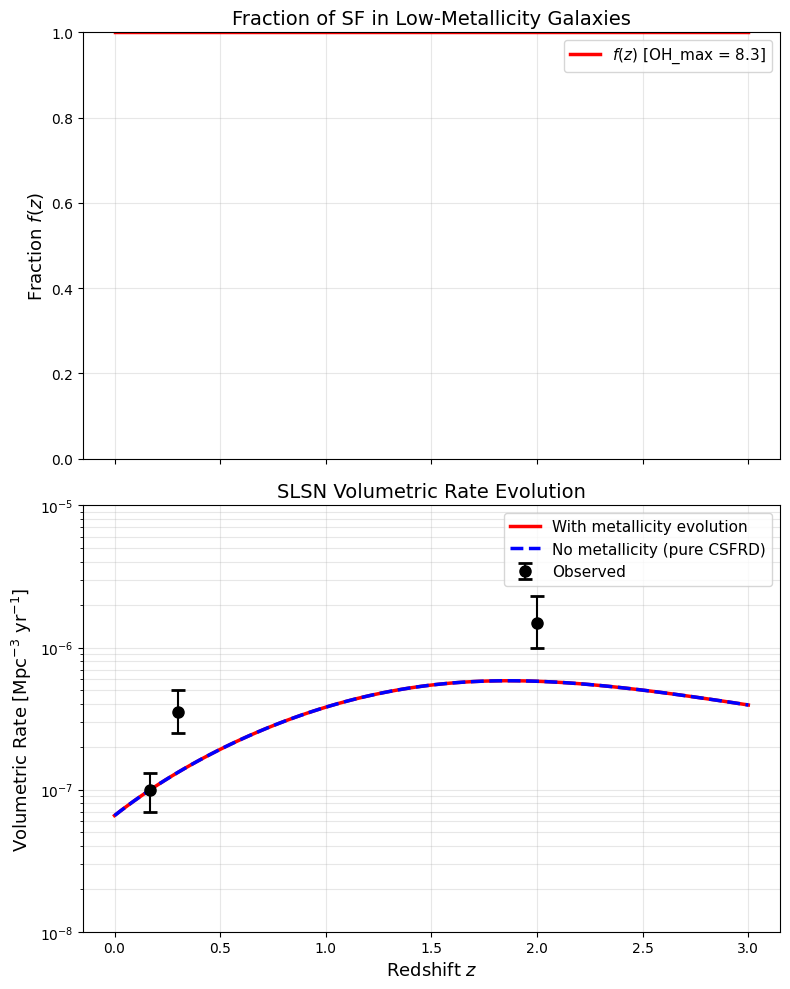

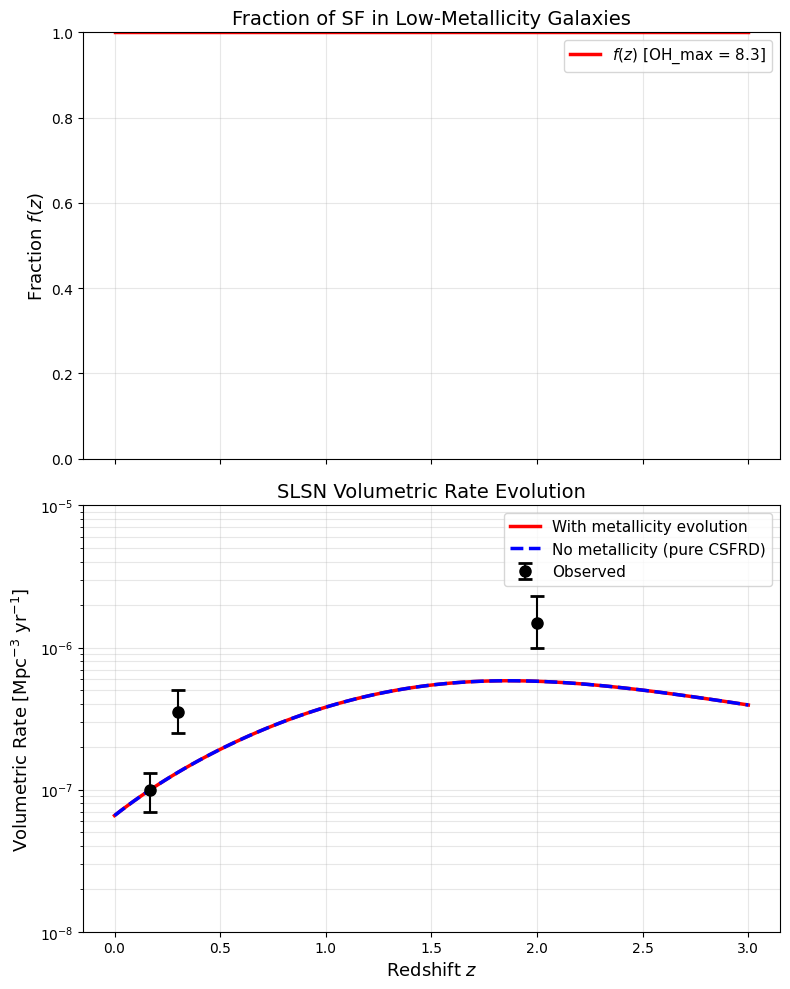

In [13]:
# ============================================================================
# CELL 6: Plot theoretical rate evolution (before generating population)
# ============================================================================

# This shows what the abstract predicts
plot_rate_evolution_comparison(
    OH_max=8.3,
    R_ref=1e-7,
    z_ref=0.17,
    save_path="/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_theory_prediction.png"
)

Valid templates: 165/261

USING RATE EVOLUTION MODEL
Reference: R(0.17) = 1.00e-07 Mpc^-3 yr^-1
Metallicity threshold: 12+log(O/H) < 8.3
Expected events from R(z) integration: 8670.7
  [z_min=0.1, z_max=0.3, t=10.0 yr]
Generated 8748 events
Redshift range: 0.100 - 0.300
Mean redshift: 0.233

[GAL LAT CUT] Applied |b| > 15.0° cut:
  Before: 8748 events
  After:  6466 events (73.9% retained)


/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_30922/3182840165.py:208: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(integrand_lowZ, dx=d_log_M)
/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_30922/3182840165.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(integrand_total, dx=d_log_M)


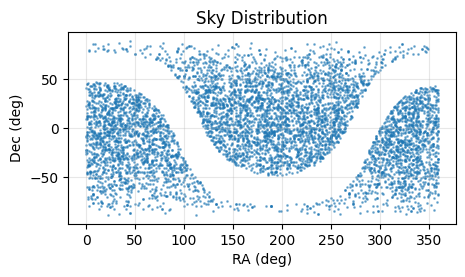

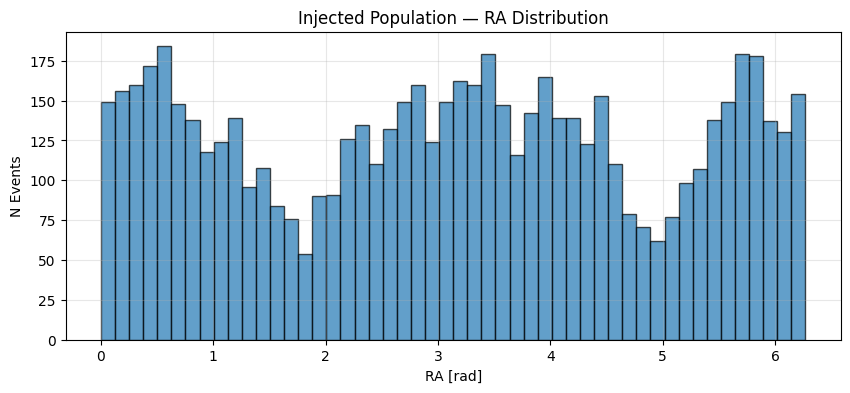

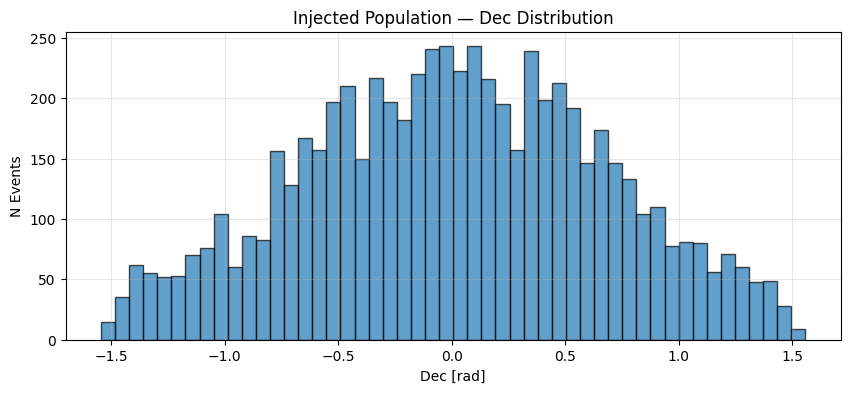

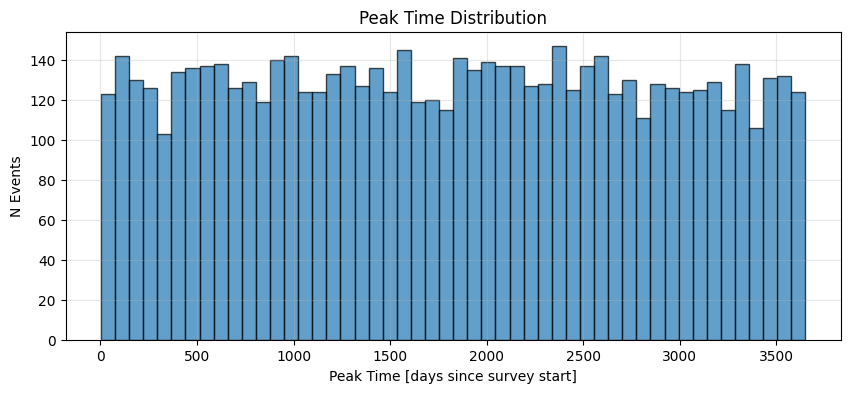

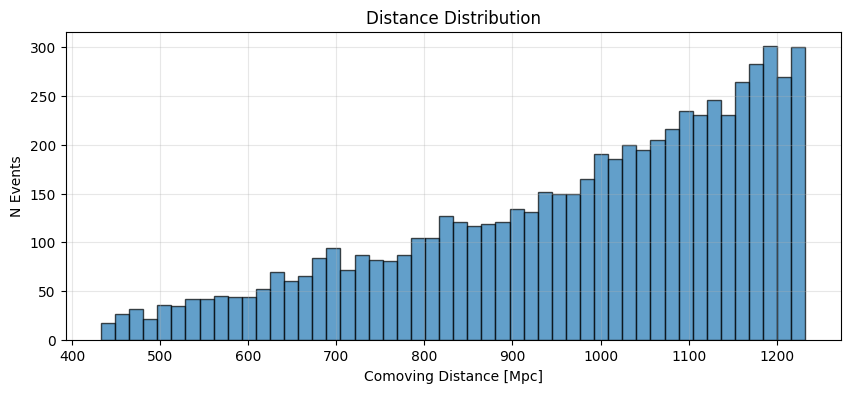

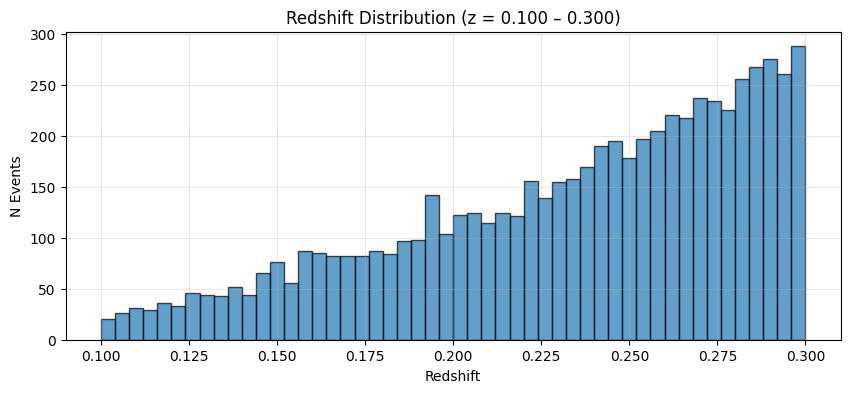

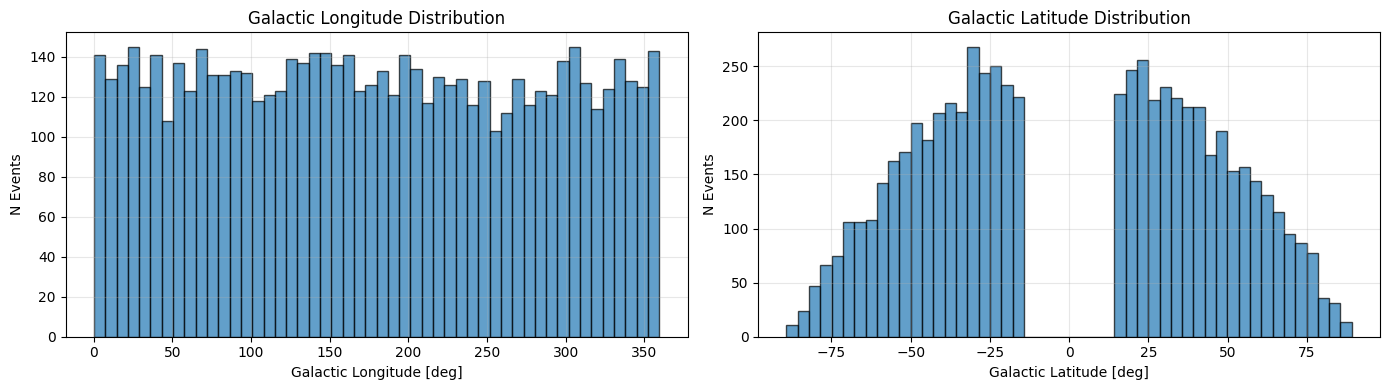

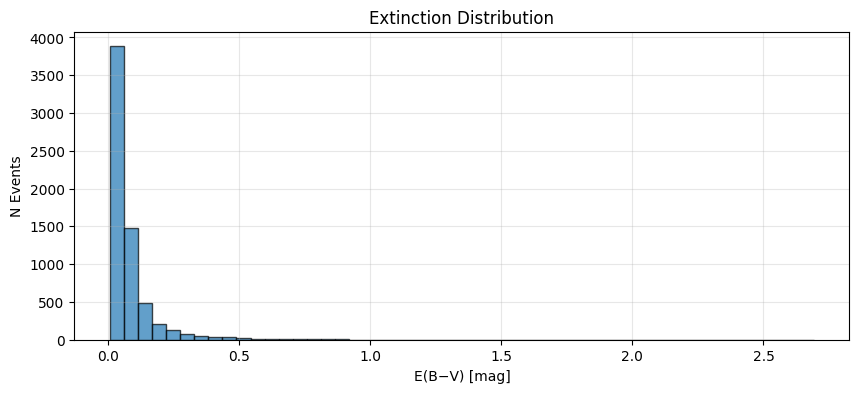

[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl
Saved SLSN population to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl

✓ Generated 6466 SLSNe


In [35]:
# ============================================================================
# CELL 7: Generate population WITH rate evolution
# ============================================================================

pop_evolving = generate_SLSN_PopSlicer_with_rate_evolution(
    lc_model=templates,
    rate_model='evolving',      # KEY: Use rate evolution!
    R_ref=1e-7,                  # Quimby+13 @ z=0.17
    z_ref=0.17,
    OH_max=8.3,                  # Schulze+21 threshold
    z_min=0.1,
    z_max=0.3,
    t_start=1,
    t_end=3652,
    gal_lat_cut=15.0,            # Optional: avoid Galactic plane
    seed=42,
    save_to=Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl"),
    make_debug_plots=True
)

print(f"\n✓ Generated {len(pop_evolving.slice_points['sid'])} SLSNe")

Valid templates: 165/261

USING CONSTANT RATE MODEL
Rate density: 1.00e-07 Mpc^-3 yr^-1 (flat across all z)
[INFO] z_min = 0.10000 -> d_min = 432.565697738352355 Mpc
[INFO] z_max = 2.00000 -> d_max = 5308.188883886385156 Mpc
Generated 626318 events

[GAL LAT CUT] Applied |b| > 15.0° cut:
  Before: 626318 events
  After:  463762 events (74.0% retained)


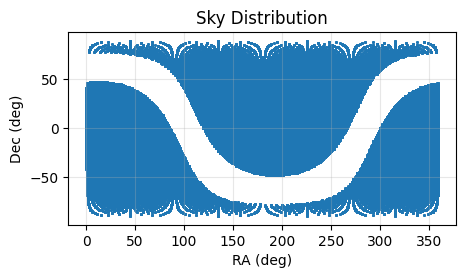

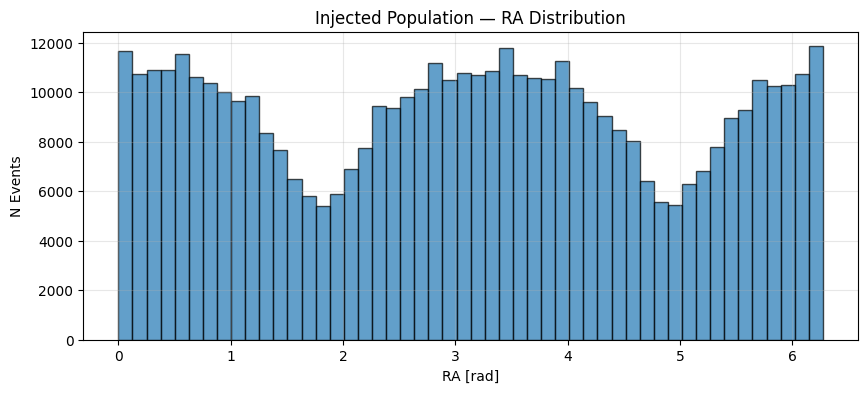

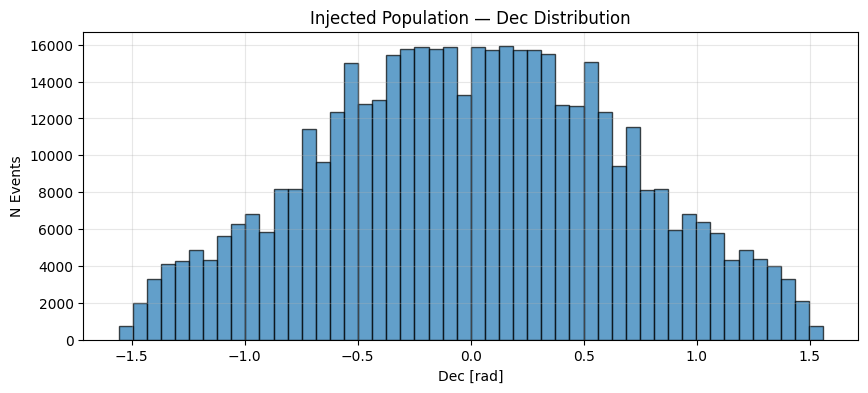

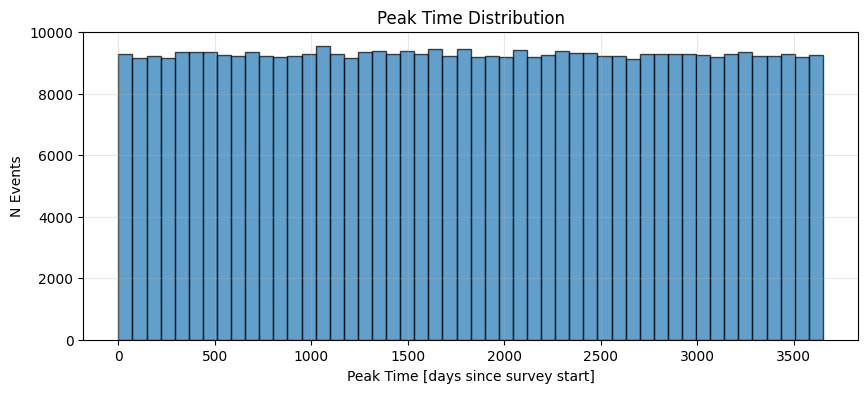

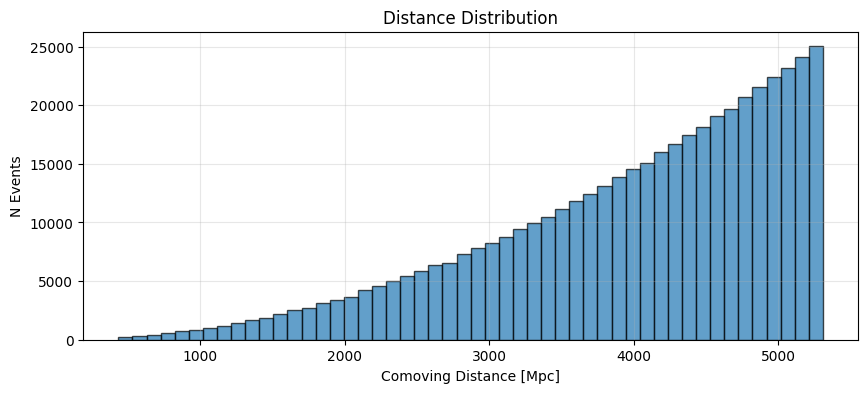

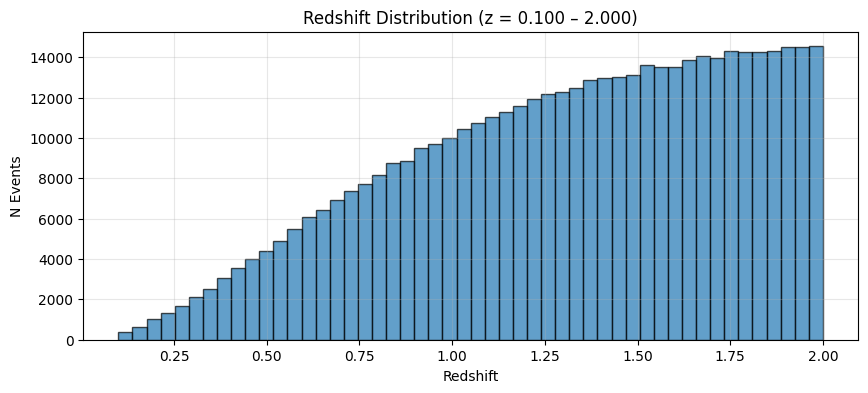

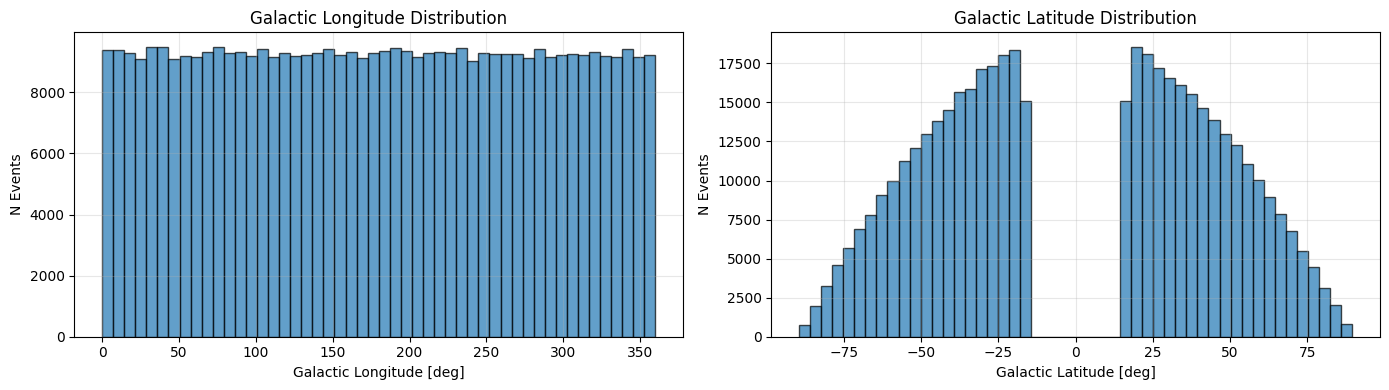

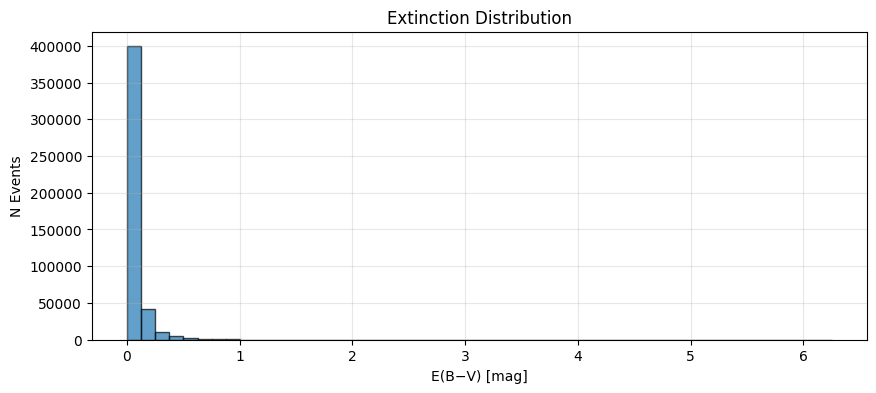

[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_constant.pkl
Saved SLSN population to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_constant.pkl

✓ Generated 463762 SLSNe


In [37]:
# ============================================================================
# CELL 8: Generate population WITHOUT rate evolution (for comparison)
# ============================================================================

pop_constant = generate_SLSN_PopSlicer_with_rate_evolution(
    lc_model=templates,
    rate_model='constant',       # OLD: Constant rate
    rate_density=1e-7,
    z_min=0.1,
    z_max=2.0,
    t_start=1,
    t_end=3652,
    gal_lat_cut=15.0,
    seed=42,
    save_to=Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_constant.pkl"),
    make_debug_plots=True
)

print(f"\n✓ Generated {len(pop_constant.slice_points['sid'])} SLSNe")

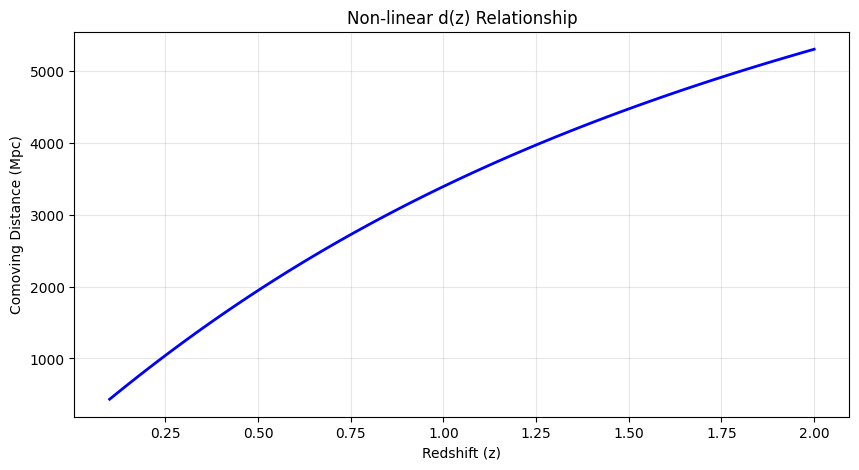

In [38]:
# In your notebook or a test script
from astropy.cosmology import Planck18 as cosmo
import numpy as np
import matplotlib.pyplot as plt

z_range = np.linspace(0.1, 2.0, 100)
d_range = cosmo.comoving_distance(z_range).value  # in Mpc

plt.figure(figsize=(10, 5))
plt.plot(z_range, d_range, 'b-', linewidth=2)
plt.xlabel('Redshift (z)')
plt.ylabel('Comoving Distance (Mpc)')
plt.title('Non-linear d(z) Relationship')
plt.grid(alpha=0.3)
plt.show()

# You'll see it's NOT a straight line!

✓ Saved to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_vs_z_evolving.png


/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_30922/3182840165.py:208: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(integrand_lowZ, dx=d_log_M)
/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_30922/3182840165.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(integrand_total, dx=d_log_M)


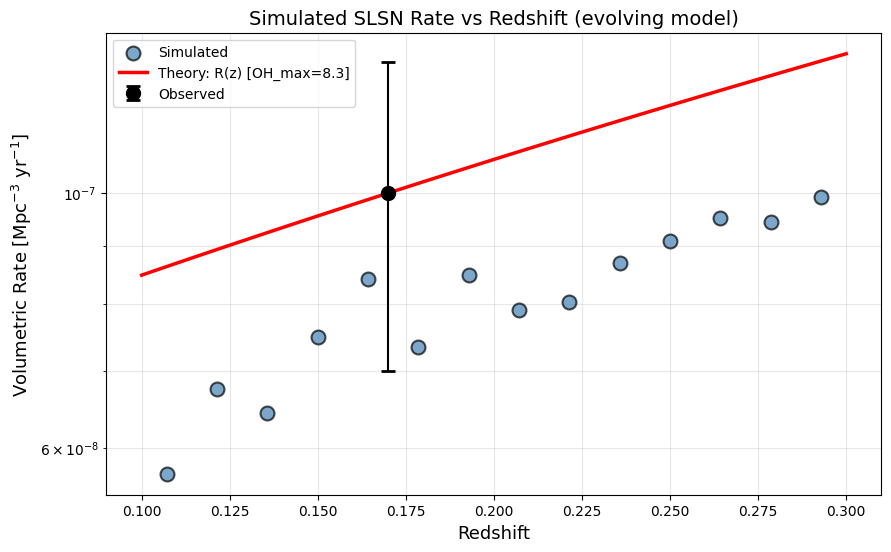

✓ Saved to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_vs_z_constant.png


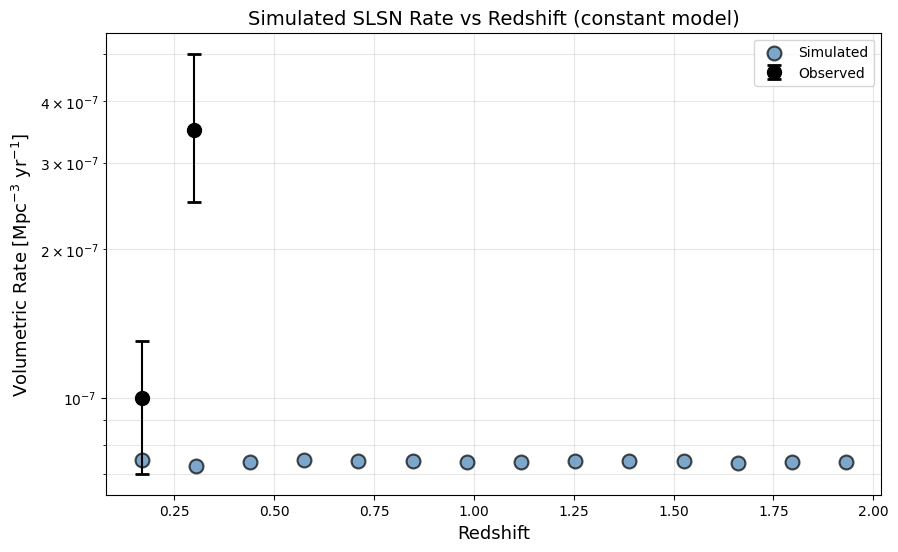

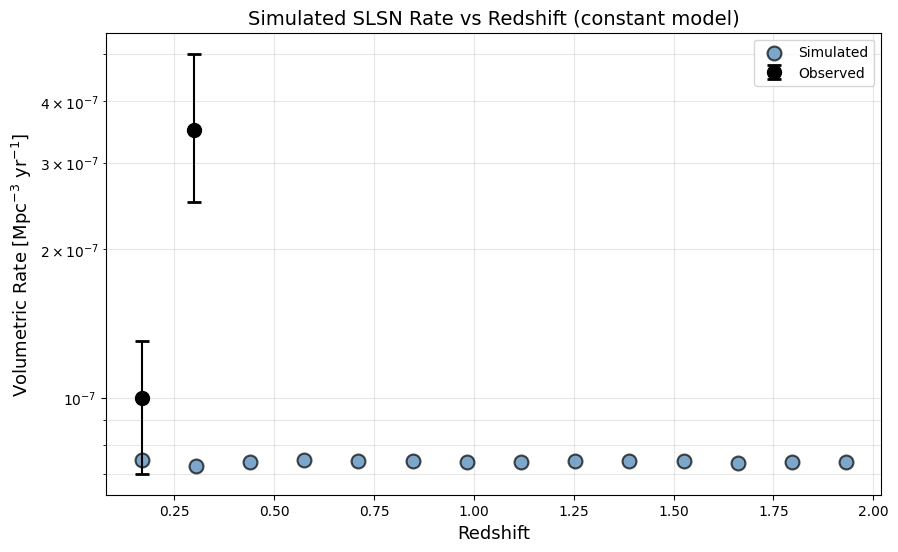

In [39]:
# ============================================================================
# CELL 10: Diagnostic plots
# ============================================================================

# Plot simulated vs theory
plot_population_rate_vs_redshift(
    pop_evolving,
    rate_model='evolving',
    R_ref=1e-7,
    z_ref=0.17,
    OH_max=8.3,
    save_path="/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_vs_z_evolving.png"
)

plot_population_rate_vs_redshift(
    pop_constant,
    rate_model='constant',
    save_path="/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/rate_vs_z_constant.png"
)

Valid templates: 165/261

USING RATE EVOLUTION MODEL
Reference: R(0.17) = 1.00e-07 Mpc^-3 yr^-1
Metallicity threshold: 12+log(O/H) < 8.3
Expected events from R(z) integration: 8670.7
  [z_min=0.1, z_max=0.3, t=10.0 yr]
Generated 8712 events
Redshift range: 0.100 - 0.300
Mean redshift: 0.233

[GAL LAT CUT] Applied |b| > 15.0° cut:
  Before: 8712 events
  After:  6435 events (73.9% retained)


/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_30922/3182840165.py:208: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(integrand_lowZ, dx=d_log_M)
/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_30922/3182840165.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(integrand_total, dx=d_log_M)


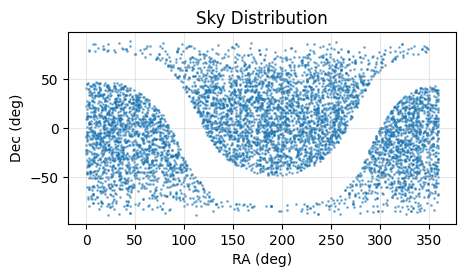

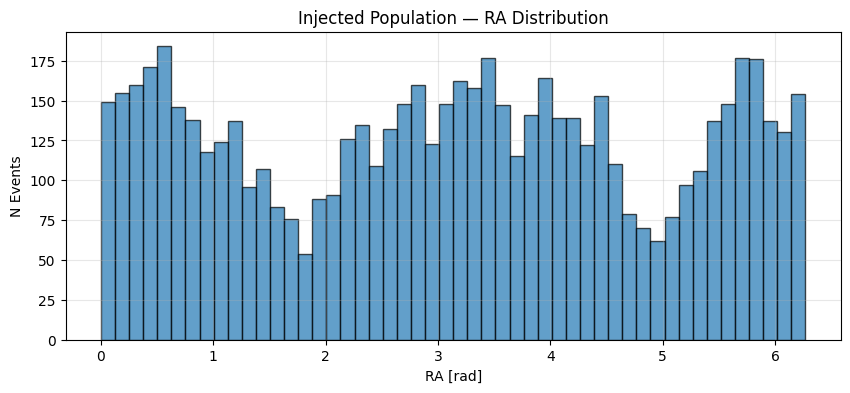

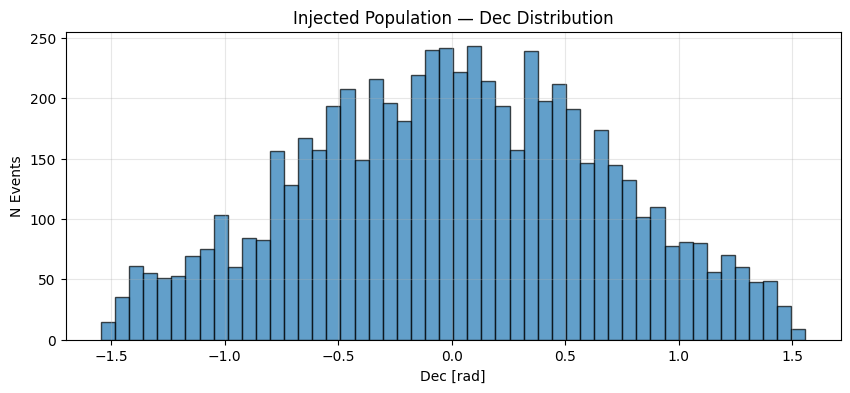

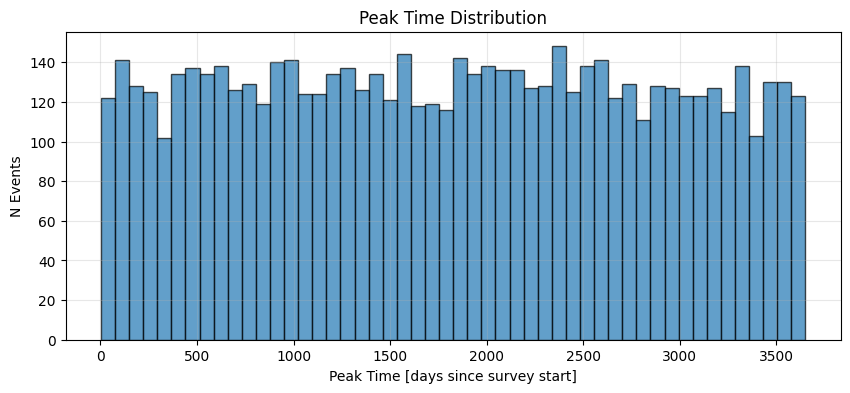

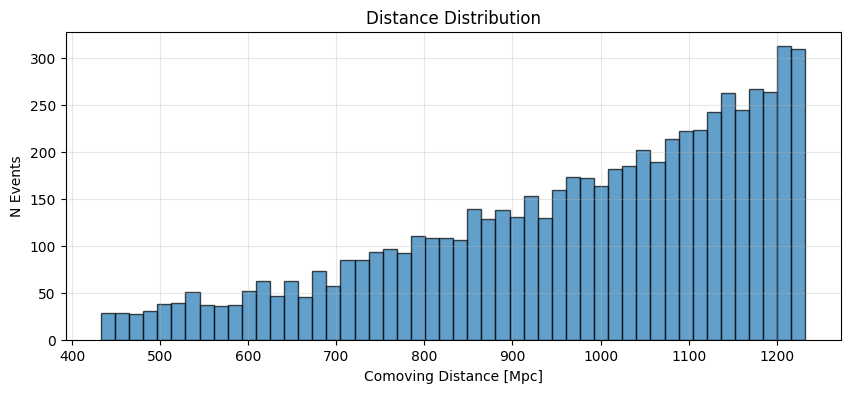

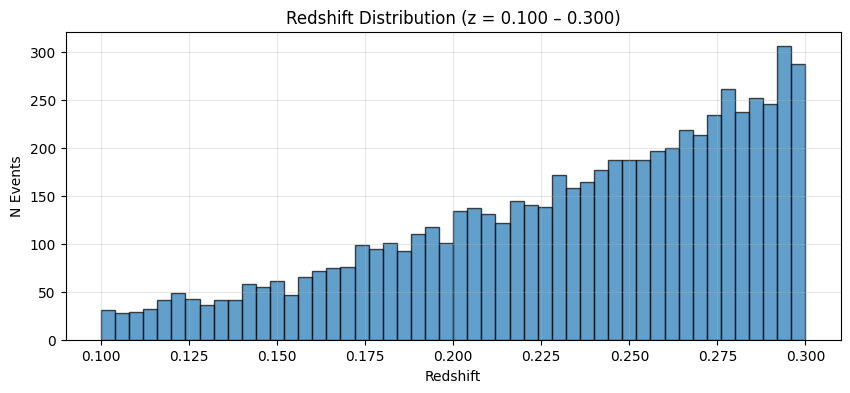

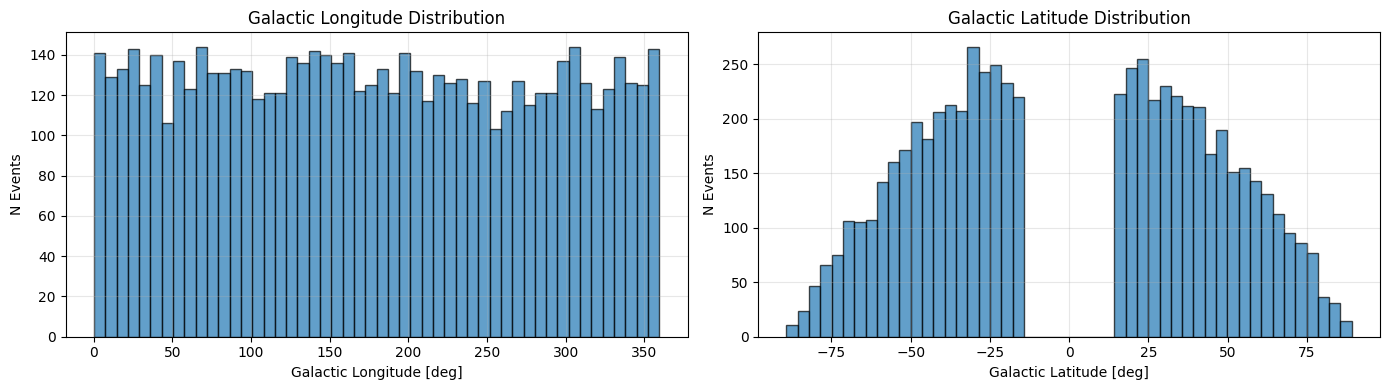

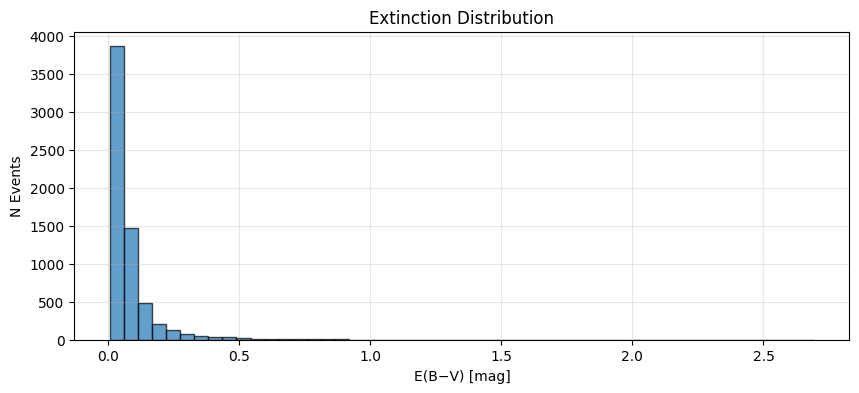

[INFO] Saved atomically to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl
Saved SLSN population to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl

✓ Generated 6435 SLSNe

Running cadence: baseline_v4.3.1_10yrs

Results for baseline_v4.3.1_10yrs:
  Events simulated: 6435
  Events detected:  315 (4.9%)
  Avg filters/detection: 5.2
  Avg observations/detection: 45.9
  Saved: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/slsn_detect_baseline_v4.3.1_10yrs.csv
  Saved: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/local_efficiency_baseline_v4.3.1_10yrs.csv
Filter testing.....
[diag] injected_peak_ebv_mag_u_cadence: finite=405
[diag] injected_peak_ebv_mag_g_cadence: finite=2187
[diag] injected_peak_ebv_mag_r_cadence: fi

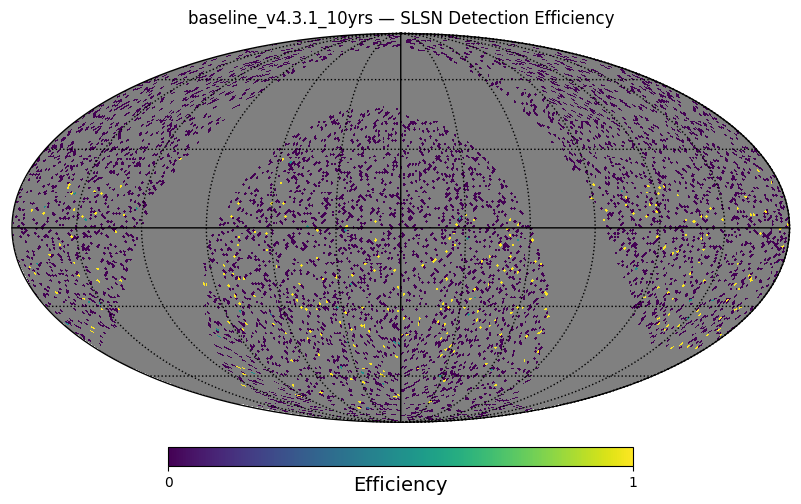

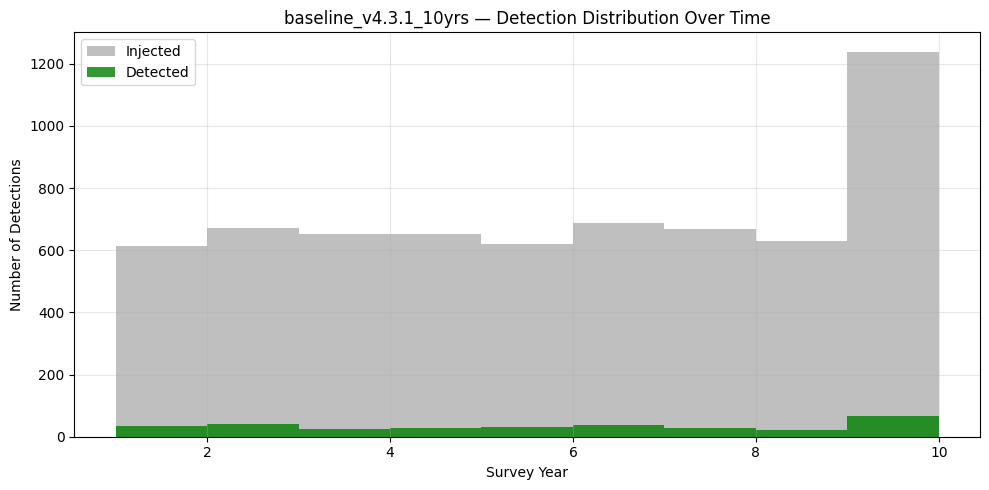

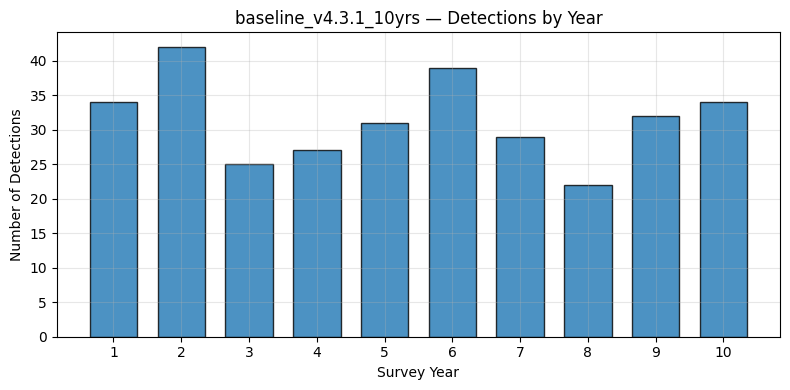

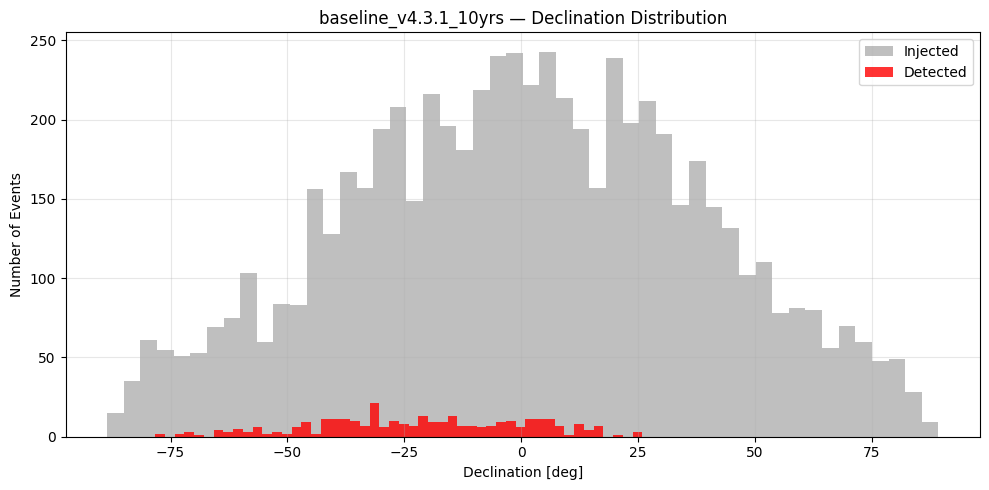

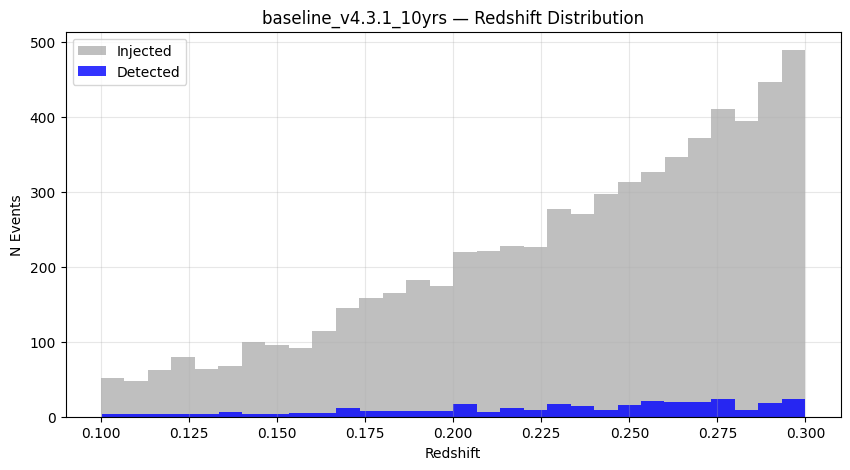

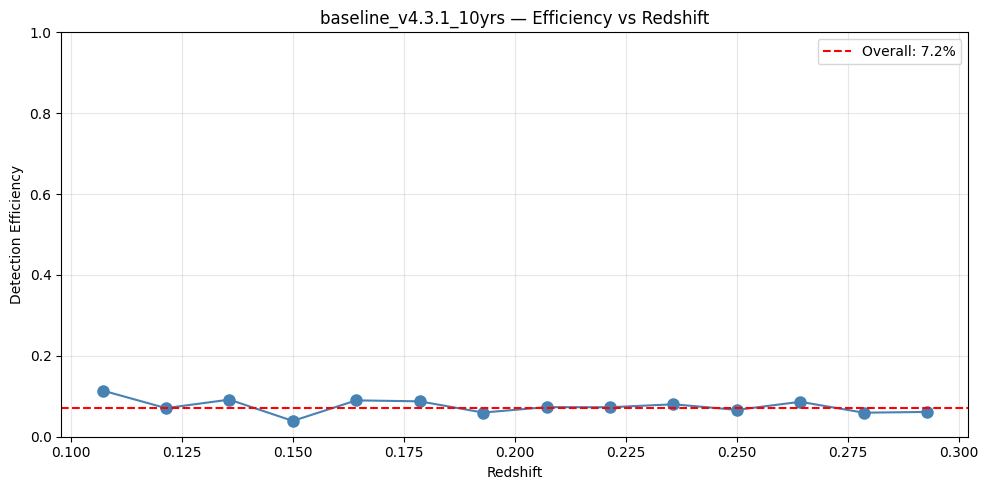

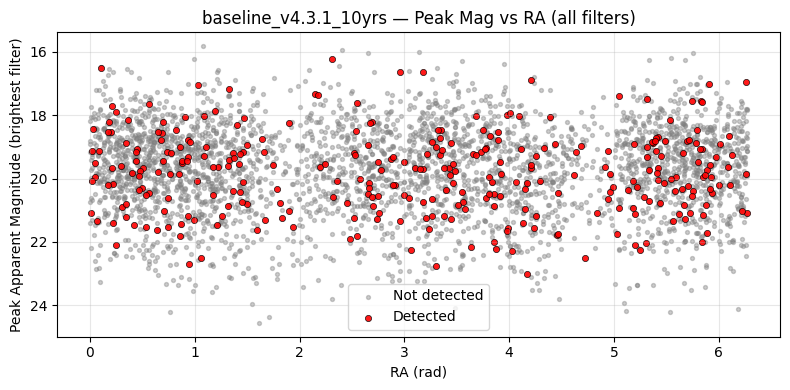

[diag] Using minimum magnitude across all filters for each event


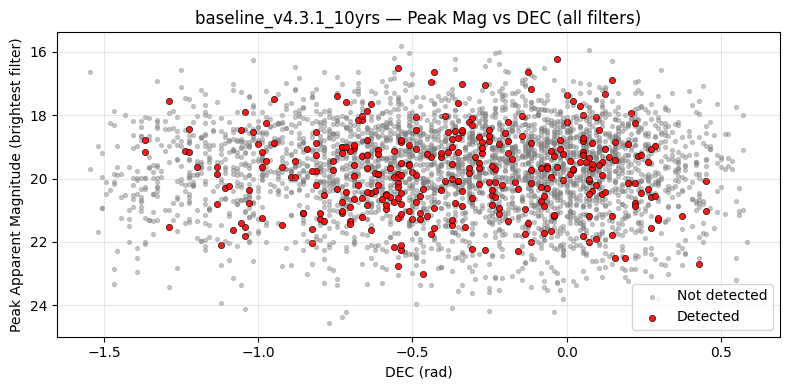

[diag] finite first_det_mjd: 3667
[diag] per_filter_min_mag present: True
[diag] finite observed-peak (r): 3110
[diag] finite injected-peak (r): 2930


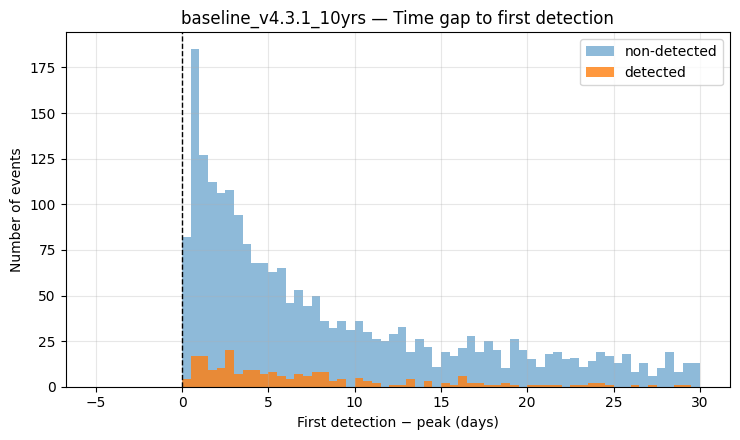

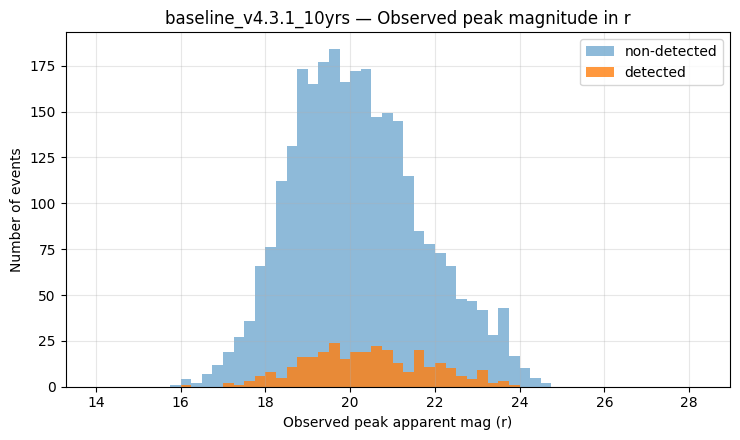

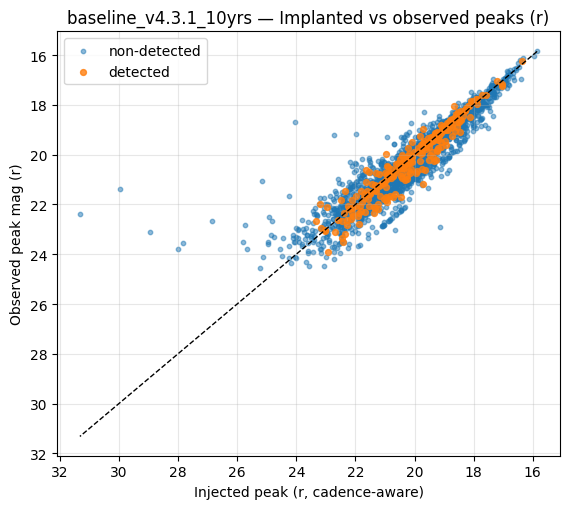

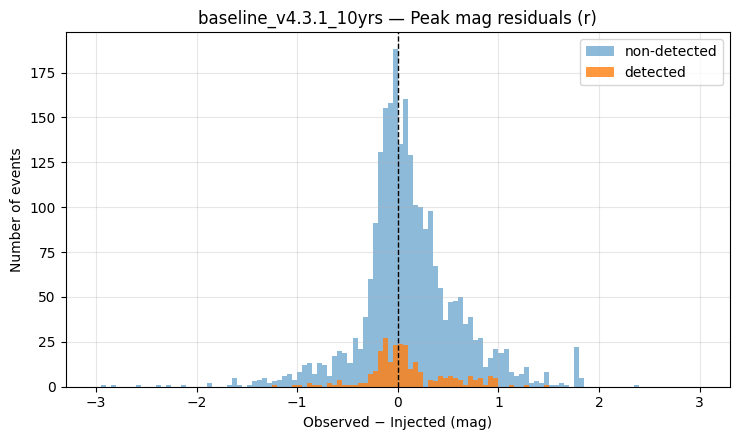

   Saved diagnostic plots
[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/Metric_temp_baseline_v4.3.1_10yrs

✓ Detection efficiency: 7.2%


In [43]:
# ============================================================================
# CELL 11: Run detection metrics (uses stable modules, no changes)
# ============================================================================

cadences = ['baseline_v4.3.1_10yrs']
db_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
output_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving")

# ============================================================================
# CELL 7: Generate population WITH rate evolution
# ============================================================================

pop_evolving = generate_SLSN_PopSlicer_with_rate_evolution(
    lc_model=templates,
    rate_model='evolving',      # KEY: Use rate evolution!
    R_ref=1e-7,                  # Quimby+13 @ z=0.17
    z_ref=0.17,
    OH_max=8.3,                  # Schulze+21 threshold
    z_min=0.1,
    z_max=0.3,
    t_start=1,
    t_end=3652,
    gal_lat_cut=15.0,            # Optional: avoid Galactic plane
    seed=42,
    save_to=Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving/pop_evolving_OH83.pkl"),
    make_debug_plots=True
)

print(f"\n✓ Generated {len(pop_evolving.slice_points['sid'])} SLSNe")


# This uses the UNCHANGED run_slsn_detect from runners.py
results_evolving, metric = run_slsn_detect(
    templates=templates,
    population=pop_evolving,
    cadences=cadences,
    db_dir=db_dir,
    output_dir=output_dir,
    store_obs_mode="full",
    make_plots=True,
    save_csv=True
)

print(f"\n✓ Detection efficiency: {results_evolving[cadences[0]]['detected'].mean():.1%}")


Running All Three SLSN Metrics on Evolving Population
Population: 6,435 events
Rate model: evolving (R_ref=1e-7, z_ref=0.17, OH_max=8.3)
Cadences: ['baseline_v4.3.1_10yrs']


Running cadence: baseline_v4.3.1_10yrs
  Running SLSN_Detect_Metric...
    Efficiency: 4.9% (315/6435)


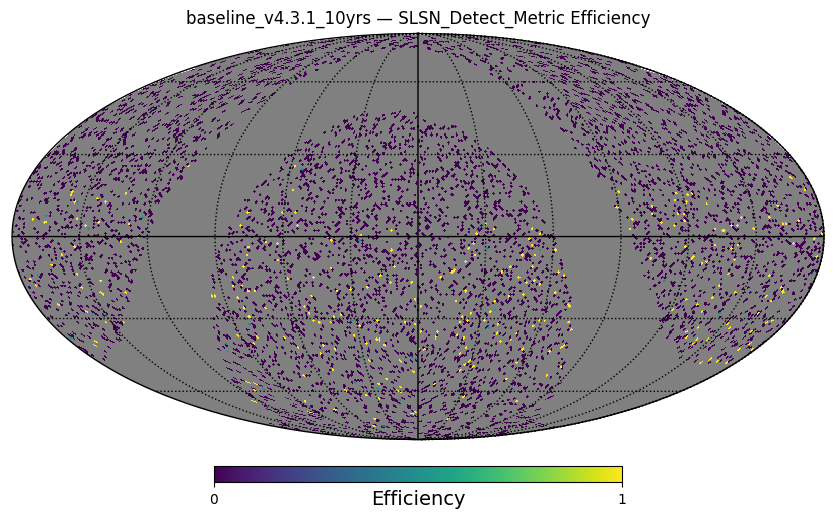

  Running SLSN_CharacterizeMetric...
    Efficiency: 2.2% (139/6435)


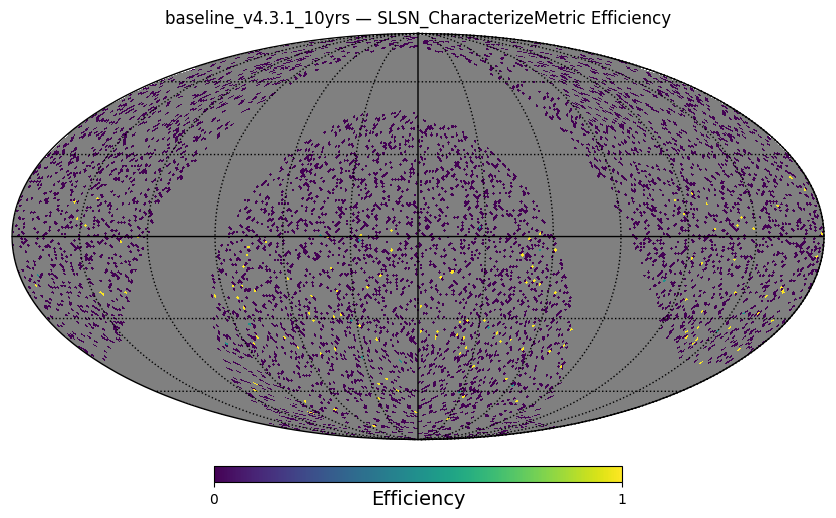

  Running SLSN_SpecTriggerMetric...
    Efficiency: 1.5% (97/6435)


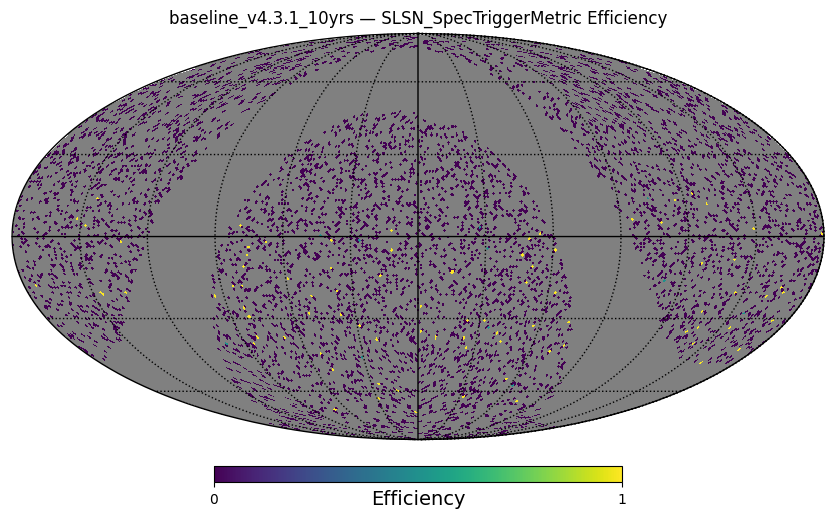


Summary saved: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving_multimet/slsn_multi_metrics_summary.csv

RESULTS: All Three Metrics (Evolving Rate Model)
              cadence                  metric  n_events  n_success  efficiency
baseline_v4.3.1_10yrs      SLSN_Detect_Metric      6435        315    0.048951
baseline_v4.3.1_10yrs SLSN_CharacterizeMetric      6435        139    0.021601
baseline_v4.3.1_10yrs  SLSN_SpecTriggerMetric      6435         97    0.015074

✓ Summary saved to /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving_multimet/evolving_rate_all_metrics_summary.csv

KEY FINDINGS
SLSN_Detect_Metric           4.9%  (    315 /   6,435)
SLSN_CharacterizeMetric      2.2%  (    139 /   6,435)
SLSN_SpecTriggerMetric       1.5%  (     97 /   6,435)



In [44]:
# ============================================================================
# CELL 12: Run All Three Metrics on Evolving Population
# ============================================================================

import os
from pathlib import Path
from slsn_metrics.metrics import (
    SLSN_Detect_Metric, 
    SLSN_CharacterizeMetric, 
    SLSN_SpecTriggerMetric
)
from slsn_metrics.runners import run_slsn_multi_metrics

# Setup paths
cadences = ['baseline_v4.3.1_10yrs']
db_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
output_dir = Path("/Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving_multimet")
output_dir.mkdir(parents=True, exist_ok=True)

mjd0 = 60980.5
ignore_triples = True

print("\n" + "="*70)
print("Running All Three SLSN Metrics on Evolving Population")
print("="*70)
print(f"Population: {len(pop_evolving.slice_points['sid']):,} events")
print(f"Rate model: evolving (R_ref=1e-7, z_ref=0.17, OH_max=8.3)")
print(f"Cadences: {cadences}")
print("="*70 + "\n")

# Create all three metrics
metrics_list = [
    SLSN_Detect_Metric(
        lc_model=templates, 
        mjd0=mjd0, 
        store_obs_mode="full"  # Use "meta" if you want obs records
    ),
    SLSN_CharacterizeMetric(
        lc_model=templates, 
        mjd0=mjd0, 
        store_obs_mode="full"
    ),
    SLSN_SpecTriggerMetric(
        lc_model=templates, 
        mjd0=mjd0, 
        store_obs_mode="full"
    )
]

# Run all metrics
summary_df = run_slsn_multi_metrics(
    templates=templates,
    population=pop_evolving,  # ← YOUR NEW EVOLVING POPULATION!
    cadences=cadences,
    db_dir=str(db_dir),
    output_dir=str(output_dir),
    metrics_list=metrics_list,
    mjd0=mjd0,
    ignore_triples=ignore_triples,
    save_summary=True,
    make_plots=True,  # HEALPix efficiency maps
    verbose=True
)

# Display results
print("\n" + "="*70)
print("RESULTS: All Three Metrics (Evolving Rate Model)")
print("="*70)
print(summary_df.to_string(index=False))
print("="*70)

# Save summary
summary_path = output_dir / "evolving_rate_all_metrics_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"\n✓ Summary saved to {summary_path}")

# Print key findings
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)
for _, row in summary_df.iterrows():
    print(f"{row['metric']:<25} {row['efficiency']*100:>6.1f}%  ({row['n_success']:>7,} / {row['n_events']:>7,})")
print("="*70 + "\n")


Running cadence: baseline_v4.3.1_10yrs
  Running SLSN_Detect_Metric...
    Efficiency: 4.9% (315/6435)


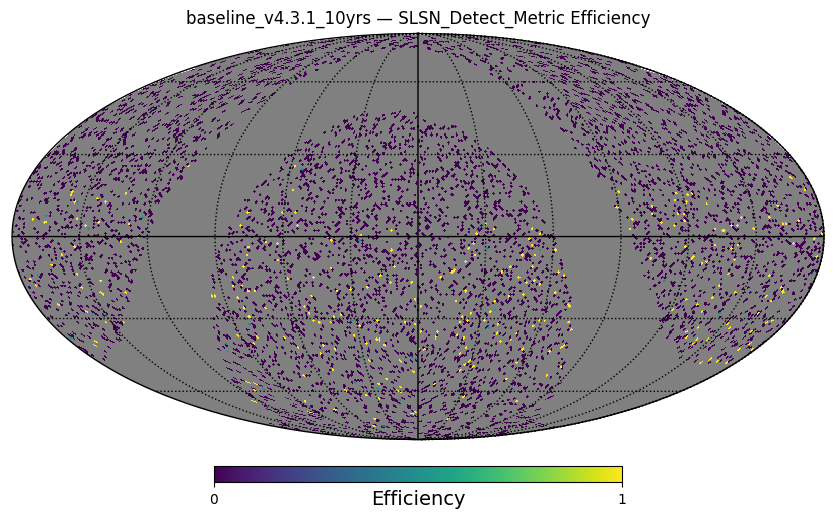

  Running SLSN_CharacterizeMetric...
    Efficiency: 2.2% (139/6435)


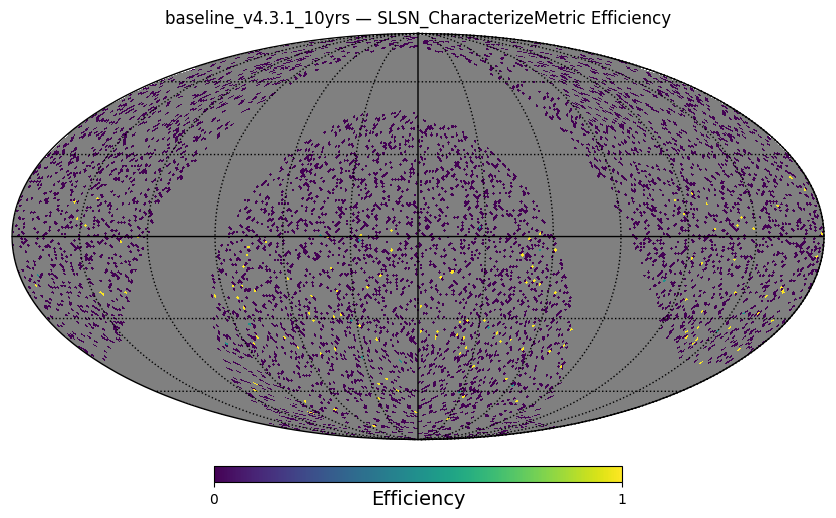

  Running SLSN_SpecTriggerMetric...
    Efficiency: 1.5% (97/6435)


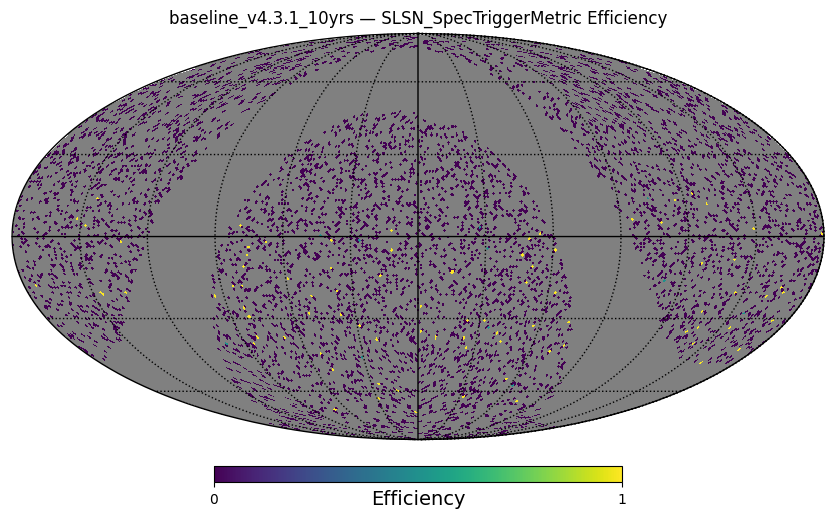


Summary saved: /Users/andradenebula/Documents/Research/Transient_Metrics/SLSNe_Metric/output/Rubin_tests/SLSNe/evolving_multimet/slsn_multi_metrics_summary.csv

                 cadence                   metric  n_events  n_success  efficiency
0  baseline_v4.3.1_10yrs       SLSN_Detect_Metric      6435        315    0.048951
1  baseline_v4.3.1_10yrs  SLSN_CharacterizeMetric      6435        139    0.021601
2  baseline_v4.3.1_10yrs   SLSN_SpecTriggerMetric      6435         97    0.015074

OBSERVATION DATA CHECK
Detect df columns: ['mjd_obs', 'mag_obs', 'snr_obs', 'filter', 'available_bands', 'detected', 'sid', 'file_indx', 'z', 'ra', 'dec', 'distance_Mpc', 'ebv', 'peak_time']
Has mjd_obs: True
Number of events: 4392


In [45]:
# Run metrics
summary_df = run_slsn_multi_metrics(
    templates=templates,
    population=pop_evolving,
    cadences=cadences,
    db_dir=str(db_dir),
    output_dir=str(output_dir),
    metrics_list=metrics_list,
    mjd0=mjd0,
    ignore_triples=ignore_triples,
    save_summary=True,
    make_plots=True,
    verbose=True
)

# Display summary
print("\n" + "="*70)
print(summary_df.to_string())
print("="*70)

# ============================================
# Extract obs_records from your metrics
# ============================================
# The metrics_list contains the SAME metric objects that were run
# Their obs_records are populated after run_slsn_multi_metrics completes

detect_metric = metrics_list[0]
char_metric = metrics_list[1]
spec_metric = metrics_list[2]

# Build dataframes from obs_records
import pandas as pd

df_detect = pd.DataFrame.from_dict(
    detect_metric.obs_records,
    orient='index'
).reset_index(drop=True)

df_char = pd.DataFrame.from_dict(
    char_metric.obs_records,
    orient='index'
).reset_index(drop=True)

df_spec = pd.DataFrame.from_dict(
    spec_metric.obs_records,
    orient='index'
).reset_index(drop=True)

# Check that we have observation data
print("\n" + "="*70)
print("OBSERVATION DATA CHECK")
print("="*70)
print(f"Detect df columns: {df_detect.columns.tolist()}")
print(f"Has mjd_obs: {'mjd_obs' in df_detect.columns}")
print(f"Number of events: {len(df_detect)}")
print("="*70)




In [26]:
# ============================================
# DIAGNOSTIC: Check what's in the dataframes
# ============================================
import pandas as pd

print("\n" + "="*70)
print("DATAFRAME DIAGNOSTICS")
print("="*70)

# Check DETECTION dataframe
print("\n1. DETECTION DataFrame:")
print(f"   Columns: {df_detect.columns.tolist()}")
print(f"   Has 'detected': {'detected' in df_detect.columns}")
if 'detected' in df_detect.columns:
    print(f"   True count: {df_detect['detected'].sum()}")
    print(f"   False count: {(~df_detect['detected']).sum()}")
    print(f"   Detection rate: {df_detect['detected'].mean():.1%}")

# Check CHARACTERIZATION dataframe
print("\n2. CHARACTERIZATION DataFrame:")
print(f"   Columns: {df_char.columns.tolist()}")
print(f"   Has 'characterized': {'characterized' in df_char.columns}")
if 'characterized' in df_char.columns:
    print(f"   True count: {df_char['characterized'].sum()}")
    print(f"   False count: {(~df_char['characterized']).sum()}")
    print(f"   Characterization rate: {df_char['characterized'].mean():.1%}")
else:
    print("   ⚠️  'characterized' column MISSING!")

# Check SPEC TRIGGER dataframe
print("\n3. SPEC TRIGGER DataFrame:")
print(f"   Columns: {df_spec.columns.tolist()}")
print(f"   Has 'spec_trigger': {'spec_trigger' in df_spec.columns}")
if 'spec_trigger' in df_spec.columns:
    print(f"   True count: {df_spec['spec_trigger'].sum()}")
    print(f"   False count: {(~df_spec['spec_trigger']).sum()}")
    print(f"   Spec trigger rate: {df_spec['spec_trigger'].mean():.1%}")
else:
    print("   ⚠️  'spec_trigger' column MISSING!")

# Check observation data
print("\n4. OBSERVATION DATA CHECK:")
required_obs_cols = ['mjd_obs', 'mag_obs', 'filter', 'snr_obs']
for col in required_obs_cols:
    print(f"   {col:15s}: detect={col in df_detect.columns}, "
          f"char={col in df_char.columns}, spec={col in df_spec.columns}")

print("="*70 + "\n")


DATAFRAME DIAGNOSTICS

1. DETECTION DataFrame:
   Columns: ['mjd_obs', 'mag_obs', 'snr_obs', 'filter', 'available_bands', 'detected', 'sid', 'file_indx', 'z', 'ra', 'dec', 'distance_Mpc', 'ebv', 'peak_time']
   Has 'detected': True
   True count: 303
   False count: 4113
   Detection rate: 6.9%

2. CHARACTERIZATION DataFrame:
   Columns: ['mjd_obs', 'mag_obs', 'snr_obs', 'filter', 'available_bands', 'characterized', 'n_epochs', 'n_filters_char']
   Has 'characterized': True
   True count: 117
   False count: 4299
   Characterization rate: 2.6%

3. SPEC TRIGGER DataFrame:
   Columns: ['mjd_obs', 'mag_obs', 'snr_obs', 'filter', 'available_bands', 'spec_trigger', 'min_mag_near_peak', 'has_g_near_peak', 'has_r_near_peak']
   Has 'spec_trigger': True
   True count: 94
   False count: 4322
   Spec trigger rate: 2.1%

4. OBSERVATION DATA CHECK:
   mjd_obs        : detect=True, char=True, spec=True
   mag_obs        : detect=True, char=True, spec=True
   filter         : detect=True, char=Tru


Detection:
  Pass: 315 / 4392 (7.2%)
  Fail: 4077 / 4392 (92.8%)
✅ Saved to output/metrics_detection.png


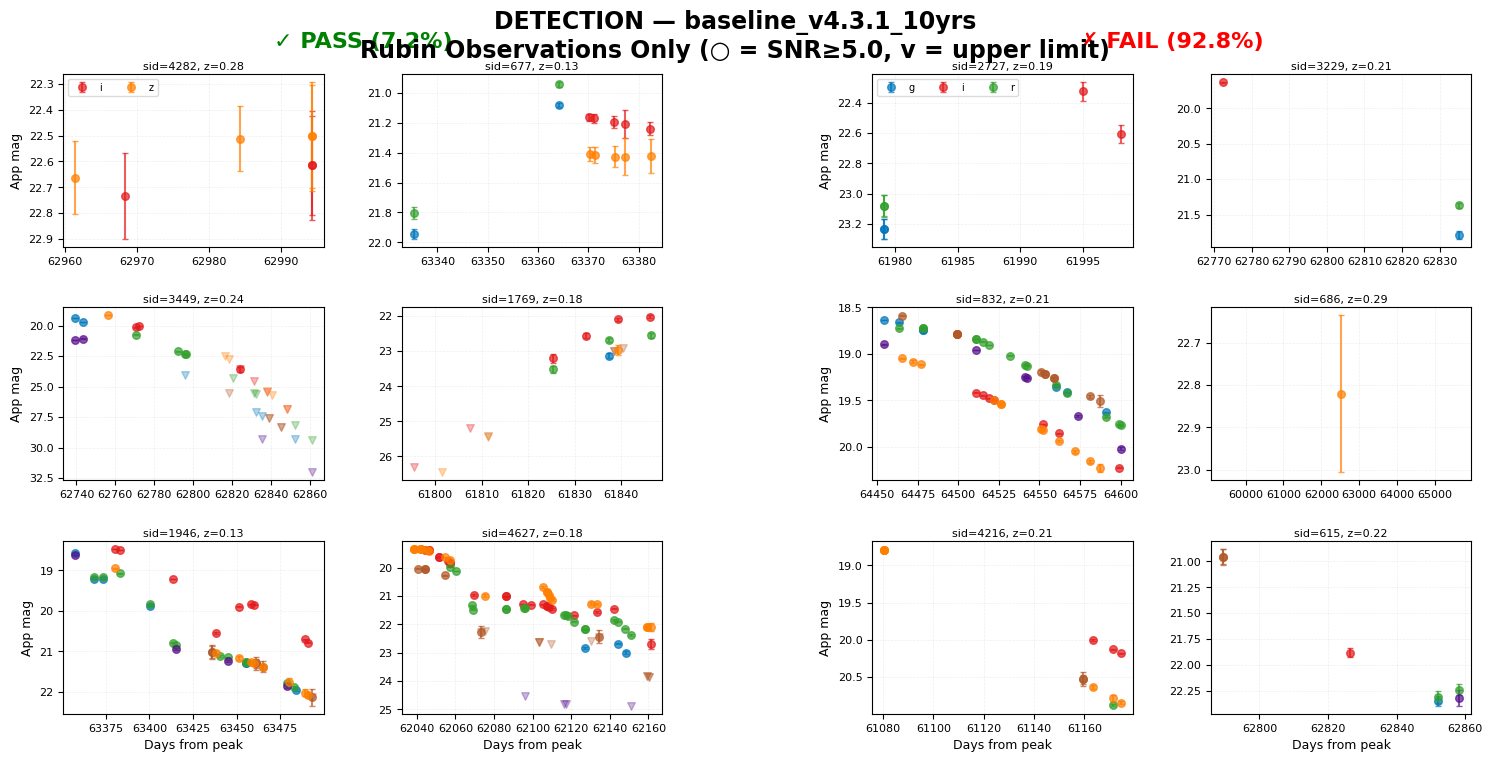


Characterization:
  Pass: 139 / 4392 (3.2%)
  Fail: 4253 / 4392 (96.8%)
✅ Saved to output/metrics_characterization.png


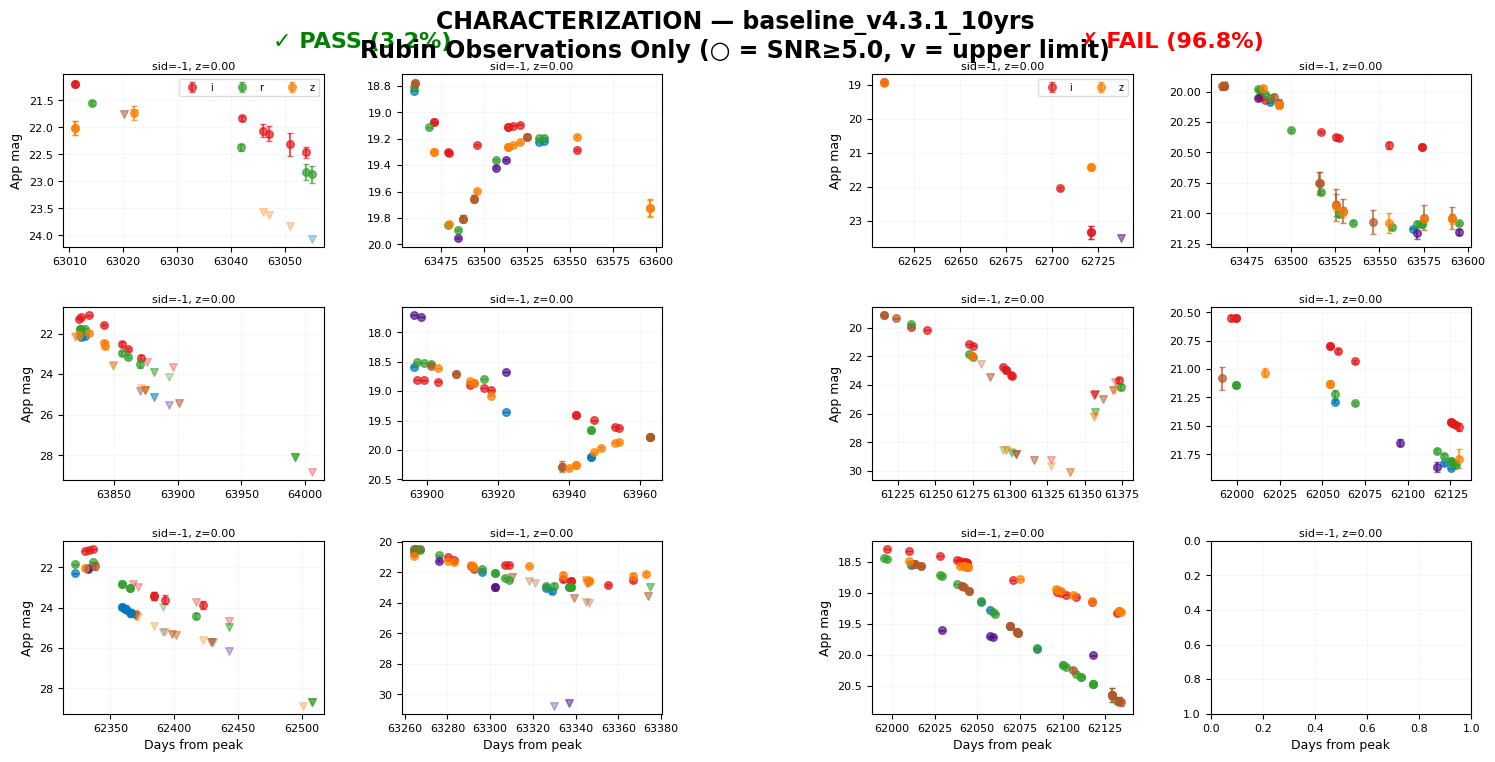


Spectroscopic Trigger:
  Pass: 97 / 4392 (2.2%)
  Fail: 4295 / 4392 (97.8%)
✅ Saved to output/metrics_spec_trigger.png


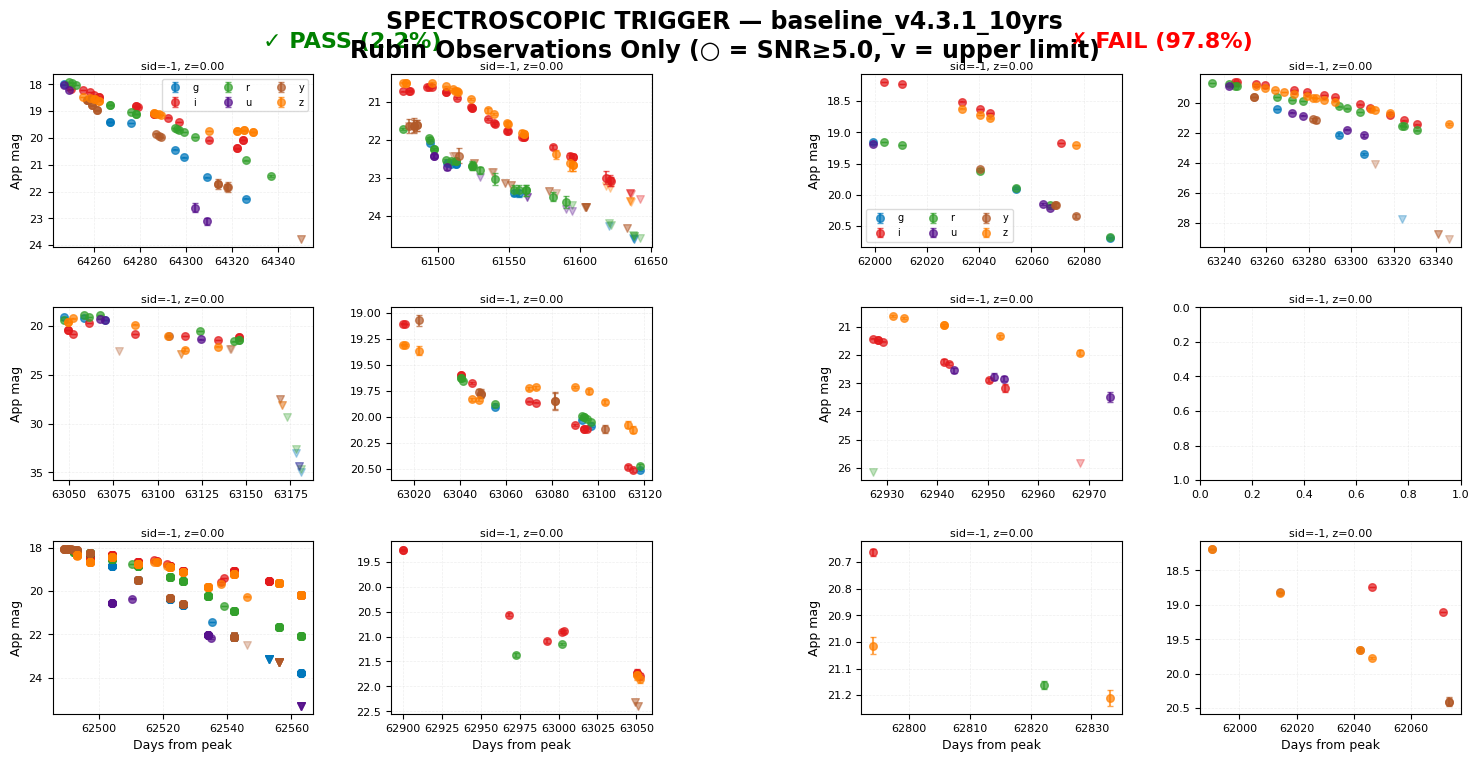


✅ Created 3 separate metric plots:
   1. output/metrics_detection.png
   2. output/metrics_characterization.png
   3. output/metrics_spec_trigger.png

Detection:
  Pass: 315 / 4392 (7.2%)
  Fail: 4077 / 4392 (92.8%)
✅ Saved to output/metrics_detection.png

Characterization:
  Pass: 139 / 4392 (3.2%)
  Fail: 4253 / 4392 (96.8%)
✅ Saved to output/metrics_characterization.png

Spectroscopic Trigger:
  Pass: 97 / 4392 (2.2%)
  Fail: 4295 / 4392 (97.8%)
✅ Saved to output/metrics_spectroscopic_trigger.png
✅ All 3 figures created and saved!

✅ Mosaic saved to output/metrics_comparison_mosaic.png


In [62]:
def plot_metrics_mosaic_grid(
    df_detect,
    df_char,
    df_spec,
    *,
    n_examples=6,
    snr_threshold=5.0,
    figsize=(18, 14),
    outpath=None,
    seed=42,
    filter_colors=None,
    marker_size=30,
    upperlim_marker='v',
    title_prefix="SLSN Metrics Comparison"
):
    """
    Create a grid mosaic with individual event subplots for Pass vs Fail.
    
    Layout: 3 rows (Detection, Characterization, Spec Trigger) × 2 columns (Pass, Fail)
    Each panel shows multiple individual event light curves in a grid.
    
    Parameters
    ----------
    df_detect : pd.DataFrame
        Detection results with 'detected' column and observation arrays
    df_char : pd.DataFrame
        Characterization results with 'characterized' column
    df_spec : pd.DataFrame
        Spec trigger results with 'spec_trigger' column
    n_examples : int
        Number of example events per Pass/Fail panel (will create grid)
    snr_threshold : float
        SNR threshold for detections vs upper limits
    figsize : tuple
        Figure size
    outpath : str or Path
        Save path
    seed : int
        Random seed for sampling
    filter_colors : dict
        Custom filter colors
    marker_size : float
        Size of observation markers
    upperlim_marker : str
        Marker for upper limits (default: 'v' for downward triangle)
    title_prefix : str
        Overall title prefix
    
    Returns
    -------
    fig : matplotlib.Figure
    
    Notes
    -----
    Add to diagnostics.py after existing plot functions.
    
    This version creates individual subplots for each event, organized in a grid.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    
    # Default filter colors
    if filter_colors is None:
        filter_colors = {
            'u': '#56108C', 'g': '#0077BB', 'r': '#33A02C',
            'i': '#E31A1C', 'z': '#FF7F00', 'y': '#B15928'
        }
    
    rng = np.random.default_rng(seed)
    
    # Helper function to plot single event in a subplot
    def plot_single_event(ax, event_row, show_legend=False):
        """Plot one event's observations with error bars and upper limits."""
        # Extract observation arrays
        mjd_obs = np.asarray(event_row.get('mjd_obs', []), dtype=float)
        mag_obs = np.asarray(event_row.get('mag_obs', []), dtype=float)
        snr_obs = np.asarray(event_row.get('snr_obs', []), dtype=float)
        filter_obs = np.asarray(event_row.get('filter', []), dtype=str)
        
        # Estimate magnitude errors from SNR: σ_m ≈ 1.0857 / SNR
        if 'magerr_obs' in event_row and event_row['magerr_obs'] is not None:
            magerr_obs = np.asarray(event_row['magerr_obs'], dtype=float)
        else:
            magerr_obs = np.where(snr_obs > 0, 1.0857 / snr_obs, np.nan)
        
        # Get event metadata
        peak_mjd = float(event_row.get('peak_mjd', 0))
        z = float(event_row.get('z', 0))
        sid = int(event_row.get('sid', -1))
        
        # Time relative to peak
        time_rel = mjd_obs - peak_mjd
        
        # Get unique filters
        filters_present = np.unique(filter_obs)
        
        # Plot each filter
        for filt in filters_present:
            mask = filter_obs == filt
            if not np.any(mask):
                continue
            
            t_filt = time_rel[mask]
            m_filt = mag_obs[mask]
            snr_filt = snr_obs[mask]
            merr_filt = magerr_obs[mask]
            
            color = filter_colors.get(filt, 'gray')
            
            # Separate detections and upper limits
            det_mask = snr_filt >= snr_threshold
            lim_mask = snr_filt < snr_threshold
            
            # Plot detections with error bars
            if np.any(det_mask):
                ax.errorbar(
                    t_filt[det_mask], m_filt[det_mask],
                    yerr=merr_filt[det_mask],
                    fmt='o', color=color, markersize=np.sqrt(marker_size),
                    alpha=0.7, capsize=2, capthick=1,
                    label=filt if show_legend else None,
                    zorder=3
                )
            
            # Plot upper limits
            if np.any(lim_mask):
                ax.scatter(
                    t_filt[lim_mask], m_filt[lim_mask],
                    marker=upperlim_marker, s=marker_size,
                    color=color, alpha=0.3, zorder=2
                )
        
        # Formatting
        ax.invert_yaxis()
        ax.grid(alpha=0.2, linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=7)
        
        # Compact title
        ax.set_title(f'sid={sid}, z={z:.2f}', fontsize=7, pad=2)
        
        if show_legend and len(filters_present) > 0:
            ax.legend(fontsize=6, ncol=3, framealpha=0.7, loc='best')
    
    # Define metrics
    metrics_data = [
        ('DETECTION', df_detect, 'detected'),
        ('CHARACTERIZATION', df_char, 'characterized'),
        ('SPEC TRIGGER', df_spec, 'spec_trigger')
    ]
    
    # Determine grid layout for events (e.g., 3x2 for 6 events)
    n_rows_per_panel = int(np.ceil(np.sqrt(n_examples)))
    n_cols_per_panel = int(np.ceil(n_examples / n_rows_per_panel))
    
    # Create figure
    fig = plt.figure(figsize=figsize)
    
    # Main GridSpec: 3 rows (metrics) × 2 columns (pass/fail)
    gs_main = GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3,
                       left=0.08, right=0.96, top=0.93, bottom=0.05)
    
    # Plot each metric
    for row_idx, (metric_name, df, status_col) in enumerate(metrics_data):
        
        # Check if status column exists
        if status_col not in df.columns:
            print(f"⚠️  Warning: '{status_col}' not found in dataframe for {metric_name}")
            print(f"    Available columns: {df.columns.tolist()}")
            # Add the column as False if missing
            df[status_col] = False
        
        # Check for observation data
        required_cols = ['mjd_obs', 'mag_obs', 'filter', 'snr_obs']
        missing_cols = [c for c in required_cols if c not in df.columns]
        if missing_cols:
            print(f"⚠️  Warning: Missing observation columns in {metric_name}: {missing_cols}")
            continue
        
        # Separate pass and fail
        pass_df = df[df[status_col] == True].copy()
        fail_df = df[df[status_col] == False].copy()
        
        n_pass = len(pass_df)
        n_fail = len(fail_df)
        
        print(f"\n{metric_name}:")
        print(f"  Pass: {n_pass} / {len(df)} ({100*n_pass/len(df):.1f}%)")
        print(f"  Fail: {n_fail} / {len(df)} ({100*n_fail/len(df):.1f}%)")
        
        # Sample examples
        n_pass_sample = min(n_examples, n_pass)
        n_fail_sample = min(n_examples, n_fail)
        
        if n_pass_sample > 0:
            pass_sample = pass_df.sample(n=n_pass_sample, random_state=seed)
        else:
            pass_sample = pass_df
        
        if n_fail_sample > 0:
            fail_sample = fail_df.sample(n=n_fail_sample, random_state=seed)
        else:
            fail_sample = fail_df
        
        # ==========================
        # PASS COLUMN (left)
        # ==========================
        gs_pass = gs_main[row_idx, 0].subgridspec(
            n_rows_per_panel, n_cols_per_panel,
            hspace=0.3, wspace=0.25
        )
        
        if len(pass_sample) > 0:
            for idx, (_, event_row) in enumerate(pass_sample.iterrows()):
                if idx >= n_examples:
                    break
                i = idx // n_cols_per_panel
                j = idx % n_cols_per_panel
                ax = fig.add_subplot(gs_pass[i, j])
                plot_single_event(ax, event_row, show_legend=(idx == 0))
                
                # Only label bottom row
                if i == n_rows_per_panel - 1:
                    ax.set_xlabel('Days from peak', fontsize=7)
                else:
                    ax.set_xlabel('')
                
                # Only label left column
                if j == 0:
                    ax.set_ylabel('App mag', fontsize=7)
                else:
                    ax.set_ylabel('')
            
            # Add Pass/Fail title at top of column
            if row_idx == 0:
                pass_rate = 100 * n_pass / len(df)
                ax_title = fig.add_subplot(gs_pass[0, :])
                ax_title.axis('off')
                ax_title.text(
                    0.5, 1.3, f'✓ PASS ({pass_rate:.1f}%)',
                    transform=ax_title.transAxes,
                    fontsize=14, fontweight='bold',
                    color='green', ha='center'
                )
        else:
            # No passing events
            ax = fig.add_subplot(gs_pass[:, :])
            ax.text(0.5, 0.5, f'No passing events\nfor {metric_name}',
                   ha='center', va='center', fontsize=11, color='gray')
            ax.axis('off')
        
        # Add row label on far left
        if row_idx == 0:
            ax_label = fig.add_subplot(gs_pass[n_rows_per_panel//2, 0])
            ax_label.text(
                -0.6, 0.5, 'DETECTION',
                transform=ax_label.transAxes,
                fontsize=13, fontweight='bold',
                rotation=90, va='center', ha='right'
            )
        elif row_idx == 1:
            ax_label = fig.add_subplot(gs_pass[n_rows_per_panel//2, 0])
            ax_label.text(
                -0.6, 0.5, 'CHARACTERIZATION',
                transform=ax_label.transAxes,
                fontsize=13, fontweight='bold',
                rotation=90, va='center', ha='right'
            )
        elif row_idx == 2:
            ax_label = fig.add_subplot(gs_pass[n_rows_per_panel//2, 0])
            ax_label.text(
                -0.6, 0.5, 'SPEC TRIGGER',
                transform=ax_label.transAxes,
                fontsize=13, fontweight='bold',
                rotation=90, va='center', ha='right'
            )
        
        # ==========================
        # FAIL COLUMN (right)
        # ==========================
        gs_fail = gs_main[row_idx, 1].subgridspec(
            n_rows_per_panel, n_cols_per_panel,
            hspace=0.3, wspace=0.25
        )
        
        if len(fail_sample) > 0:
            for idx, (_, event_row) in enumerate(fail_sample.iterrows()):
                if idx >= n_examples:
                    break
                i = idx // n_cols_per_panel
                j = idx % n_cols_per_panel
                ax = fig.add_subplot(gs_fail[i, j])
                plot_single_event(ax, event_row, show_legend=(idx == 0))
                
                # Only label bottom row
                if i == n_rows_per_panel - 1:
                    ax.set_xlabel('Days from peak', fontsize=7)
                else:
                    ax.set_xlabel('')
                
                # Only label left column
                if j == 0:
                    ax.set_ylabel('App mag', fontsize=7)
                else:
                    ax.set_ylabel('')
            
            # Add Pass/Fail title at top of column
            if row_idx == 0:
                fail_rate = 100 * n_fail / len(df)
                ax_title = fig.add_subplot(gs_fail[0, :])
                ax_title.axis('off')
                ax_title.text(
                    0.5, 1.3, f'✗ FAIL ({fail_rate:.1f}%)',
                    transform=ax_title.transAxes,
                    fontsize=14, fontweight='bold',
                    color='red', ha='center'
                )
        else:
            # No failing events
            ax = fig.add_subplot(gs_fail[:, :])
            ax.text(0.5, 0.5, f'No failing events\nfor {metric_name}',
                   ha='center', va='center', fontsize=11, color='gray')
            ax.axis('off')
    
    # Overall title
    fig.suptitle(
        f'{title_prefix}\nRubin Observations Only (○ = SNR≥5, {upperlim_marker} = upper limit)',
        fontsize=15, fontweight='bold', y=0.97
    )
    
    # Save if requested
    if outpath is not None:
        plt.savefig(outpath, dpi=150, bbox_inches='tight')
        print(f"\n✅ Saved mosaic to {outpath}")
    
    return fig

def plot_single_metric_grid(
    df,
    status_col,
    metric_name,
    *,
    n_examples=6,
    snr_threshold=5.0,
    figsize=(16, 8),
    outpath=None,
    seed=42,
    filter_colors=None,
    marker_size=30,
    upperlim_marker='v',
    cadence_name="baseline"
):
    """
    Create a 1×2 grid showing Pass vs Fail for a single metric.
    
    Parameters
    ----------
    df : pd.DataFrame
        Results dataframe with observation arrays
    status_col : str
        Column name for pass/fail status ('detected', 'characterized', 'spec_trigger')
    metric_name : str
        Display name for the metric
    n_examples : int
        Number of example events per Pass/Fail panel
    snr_threshold : float
        SNR threshold for detections vs upper limits
    figsize : tuple
        Figure size (width, height)
    outpath : str or Path
        Save path
    seed : int
        Random seed for sampling
    filter_colors : dict
        Custom filter colors
    marker_size : float
        Size of observation markers
    upperlim_marker : str
        Marker for upper limits
    cadence_name : str
        Cadence name for title
    
    Returns
    -------
    fig : matplotlib.Figure
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    
    # Default filter colors
    if filter_colors is None:
        filter_colors = {
            'u': '#56108C', 'g': '#0077BB', 'r': '#33A02C',
            'i': '#E31A1C', 'z': '#FF7F00', 'y': '#B15928'
        }
    
    rng = np.random.default_rng(seed)
    
    # Helper function to plot single event
    def plot_single_event(ax, event_row, show_legend=False):
        """Plot one event's observations."""
        mjd_obs = np.asarray(event_row.get('mjd_obs', []), dtype=float)
        mag_obs = np.asarray(event_row.get('mag_obs', []), dtype=float)
        snr_obs = np.asarray(event_row.get('snr_obs', []), dtype=float)
        filter_obs = np.asarray(event_row.get('filter', []), dtype=str)
        
        if 'magerr_obs' in event_row and event_row['magerr_obs'] is not None:
            magerr_obs = np.asarray(event_row['magerr_obs'], dtype=float)
        else:
            magerr_obs = np.where(snr_obs > 0, 1.0857 / snr_obs, np.nan)
        
        peak_mjd = float(event_row.get('peak_mjd', 0))
        z = float(event_row.get('z', 0))
        sid = int(event_row.get('sid', -1))
        
        time_rel = mjd_obs - peak_mjd
        filters_present = np.unique(filter_obs)
        
        for filt in filters_present:
            mask = filter_obs == filt
            if not np.any(mask):
                continue
            
            t_filt = time_rel[mask]
            m_filt = mag_obs[mask]
            snr_filt = snr_obs[mask]
            merr_filt = magerr_obs[mask]
            
            color = filter_colors.get(filt, 'gray')
            
            det_mask = snr_filt >= snr_threshold
            lim_mask = snr_filt < snr_threshold
            
            if np.any(det_mask):
                ax.errorbar(
                    t_filt[det_mask], m_filt[det_mask],
                    yerr=merr_filt[det_mask],
                    fmt='o', color=color, markersize=np.sqrt(marker_size),
                    alpha=0.7, capsize=2, capthick=1,
                    label=filt if show_legend else None,
                    zorder=3
                )
            
            if np.any(lim_mask):
                ax.scatter(
                    t_filt[lim_mask], m_filt[lim_mask],
                    marker=upperlim_marker, s=marker_size,
                    color=color, alpha=0.3, zorder=2
                )
        
        ax.invert_yaxis()
        ax.grid(alpha=0.2, linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=8)
        ax.set_title(f'sid={sid}, z={z:.2f}', fontsize=8, pad=3)
        
        if show_legend and len(filters_present) > 0:
            ax.legend(fontsize=7, ncol=3, framealpha=0.7, loc='best')
    
    # Check if status column exists
    if status_col not in df.columns:
        print(f"⚠️  Warning: '{status_col}' not found in dataframe")
        print(f"    Available columns: {df.columns.tolist()}")
        df[status_col] = False
    
    # Check for observation data
    required_cols = ['mjd_obs', 'mag_obs', 'filter', 'snr_obs']
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        print(f"⚠️  Warning: Missing observation columns: {missing_cols}")
        return None
    
    # Separate pass and fail
    pass_df = df[df[status_col] == True].copy()
    fail_df = df[df[status_col] == False].copy()
    
    n_pass = len(pass_df)
    n_fail = len(fail_df)
    
    print(f"\n{metric_name}:")
    print(f"  Pass: {n_pass} / {len(df)} ({100*n_pass/len(df):.1f}%)")
    print(f"  Fail: {n_fail} / {len(df)} ({100*n_fail/len(df):.1f}%)")
    
    # Sample examples
    n_pass_sample = min(n_examples, n_pass)
    n_fail_sample = min(n_examples, n_fail)
    
    if n_pass_sample > 0:
        pass_sample = pass_df.sample(n=n_pass_sample, random_state=seed)
    else:
        pass_sample = pass_df
    
    if n_fail_sample > 0:
        fail_sample = fail_df.sample(n=n_fail_sample, random_state=seed)
    else:
        fail_sample = fail_df
    
    # Grid layout (e.g., 3×2 for 6 events)
    n_rows = int(np.ceil(np.sqrt(n_examples)))
    n_cols = int(np.ceil(n_examples / n_rows))
    
    # Create figure
    fig = plt.figure(figsize=figsize)
    
    # GridSpec: 1 row × 2 columns (Pass, Fail)
    gs_main = GridSpec(1, 2, figure=fig, hspace=0.35, wspace=0.35,
                       left=0.08, right=0.96, top=0.88, bottom=0.08)
    
    # ==========================
    # PASS COLUMN (left)
    # ==========================
    gs_pass = gs_main[0, 0].subgridspec(n_rows, n_cols, hspace=0.35, wspace=0.3)
    
    if len(pass_sample) > 0:
        for idx, (_, event_row) in enumerate(pass_sample.iterrows()):
            if idx >= n_examples:
                break
            i = idx // n_cols
            j = idx % n_cols
            ax = fig.add_subplot(gs_pass[i, j])
            plot_single_event(ax, event_row, show_legend=(idx == 0))
            
            if i == n_rows - 1:
                ax.set_xlabel('Days from peak', fontsize=9)
            if j == 0:
                ax.set_ylabel('App mag', fontsize=9)
        
        # Column title
        pass_rate = 100 * n_pass / len(df)
        ax_title = fig.add_subplot(gs_pass[0, :])
        ax_title.axis('off')
        ax_title.text(
            0.5, 1.15, f'✓ PASS ({pass_rate:.1f}%)',
            transform=ax_title.transAxes,
            fontsize=16, fontweight='bold',
            color='green', ha='center'
        )
    else:
        ax = fig.add_subplot(gs_pass[:, :])
        ax.text(0.5, 0.5, 'No passing events',
               ha='center', va='center', fontsize=13, color='gray')
        ax.axis('off')
    
    # ==========================
    # FAIL COLUMN (right)
    # ==========================
    gs_fail = gs_main[0, 1].subgridspec(n_rows, n_cols, hspace=0.35, wspace=0.3)
    
    if len(fail_sample) > 0:
        for idx, (_, event_row) in enumerate(fail_sample.iterrows()):
            if idx >= n_examples:
                break
            i = idx // n_cols
            j = idx % n_cols
            ax = fig.add_subplot(gs_fail[i, j])
            plot_single_event(ax, event_row, show_legend=(idx == 0))
            
            if i == n_rows - 1:
                ax.set_xlabel('Days from peak', fontsize=9)
            if j == 0:
                ax.set_ylabel('App mag', fontsize=9)
        
        # Column title
        fail_rate = 100 * n_fail / len(df)
        ax_title = fig.add_subplot(gs_fail[0, :])
        ax_title.axis('off')
        ax_title.text(
            0.5, 1.15, f'✗ FAIL ({fail_rate:.1f}%)',
            transform=ax_title.transAxes,
            fontsize=16, fontweight='bold',
            color='red', ha='center'
        )
    else:
        ax = fig.add_subplot(gs_fail[:, :])
        ax.text(0.5, 0.5, 'No failing events',
               ha='center', va='center', fontsize=13, color='gray')
        ax.axis('off')
    
    # Overall title
    fig.suptitle(
        f'{metric_name.upper()} — {cadence_name}\n'
        f'Rubin Observations Only (○ = SNR≥{snr_threshold}, {upperlim_marker} = upper limit)',
        fontsize=17, fontweight='bold', y=0.96
    )
    
    # Save
    if outpath is not None:
        plt.savefig(outpath, dpi=150, bbox_inches='tight')
        print(f"✅ Saved to {outpath}")
    
    return fig


# ==============================================================================
# USAGE: Create 3 separate figures
# ==============================================================================

from pathlib import Path

# Create output directory if needed
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# 1. DETECTION
fig_detect = plot_single_metric_grid(
    df_detect,
    status_col='detected',
    metric_name='Detection',
    n_examples=6,
    figsize=(16, 8),
    outpath=output_dir / "metrics_detection.png",
    seed=42,
    cadence_name=cadences[0]
)
plt.show()

# 2. CHARACTERIZATION
fig_char = plot_single_metric_grid(
    df_char,
    status_col='characterized',
    metric_name='Characterization',
    n_examples=6,
    figsize=(16, 8),
    outpath=output_dir / "metrics_characterization.png",
    seed=42,
    cadence_name=cadences[0]
)
plt.show()

# 3. SPEC TRIGGER
fig_spec = plot_single_metric_grid(
    df_spec,
    status_col='spec_trigger',
    metric_name='Spectroscopic Trigger',
    n_examples=6,
    figsize=(16, 8),
    outpath=output_dir / "metrics_spec_trigger.png",
    seed=42,
    cadence_name=cadences[0]
)
plt.show()

print(f"\n{'='*70}")
print("✅ Created 3 separate metric plots:")
print(f"   1. {output_dir / 'metrics_detection.png'}")
print(f"   2. {output_dir / 'metrics_characterization.png'}")
print(f"   3. {output_dir / 'metrics_spec_trigger.png'}")
print(f"{'='*70}")

# Create all figures without showing
figs = {}
for metric_info in [
    ('detected', 'Detection', df_detect),
    ('characterized', 'Characterization', df_char),
    ('spec_trigger', 'Spectroscopic Trigger', df_spec)
]:
    status_col, name, df = metric_info
    
    fig = plot_single_metric_grid(
        df,
        status_col=status_col,
        metric_name=name,
        n_examples=6,
        figsize=(16, 8),
        outpath=output_dir / f"metrics_{name.lower().replace(' ', '_')}.png",
        seed=42,
        cadence_name=cadences[0]
    )
    figs[name] = fig
    plt.close()  # Close to save memory

print("✅ All 3 figures created and saved!")
plt.show()
print(f"\n✅ Mosaic saved to {output_dir / 'metrics_comparison_mosaic.png'}")

In [28]:

# ============================================================================
# CELL 9: Compare simulated vs observed rates
# ============================================================================

print("="*80)
print("EVOLVING RATE MODEL")
print("="*80)
df_evolving = compare_simulated_vs_observed_rates(pop_evolving)

print("\n" + "="*80)
print("CONSTANT RATE MODEL")
print("="*80)
df_constant = compare_simulated_vs_observed_rates(pop_constant)

EVOLVING RATE MODEL

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
0.00e+00 3.00e-01 1.50e-01      6468     7.85e+09        8.25e-08       1.00e-07       8.25e-01 Quimby+13
3.00e-01 6.00e-01 4.50e-01         0     4.13e+10        0.00e+00       3.50e-07       0.00e+00  Prajs+17
6.00e-01 1.00e+00 8.00e-01         0     1.15e+11        0.00e+00            NaN            NaN         —
1.00e+00 1.50e+00 1.25e+00         0     2.12e+11        0.00e+00            NaN            NaN         —
1.50e+00 2.50e+00 2.00e+00         0     5.14e+11        0.00e+00       1.50e-06       0.00e+00  Cooke+12


CONSTANT RATE MODEL

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
0.00e+00 3.00e-01 1.50e-01      5525     7.85e+09        7.04e-08       1.00e-07       7.04e-01 Quimby+13
3.00e-01 6.00e-01 4.50e-01     3

In [ ]:
# ============================================================================
# CELL 12: Sensitivity analysis - vary metallicity threshold
# ============================================================================

OH_values = [8.2, 8.3, 8.4]  # ±0.1 dex around Schulze+21

for OH_max in OH_values:
    print(f"\n{'='*70}")
    print(f"Testing OH_max = {OH_max}")
    print(f"{'='*70}")
    
    pop_test = generate_SLSN_PopSlicer_with_rate_evolution(
        lc_model=templates,
        rate_model='evolving',
        R_ref=1e-7,
        z_ref=0.17,
        OH_max=OH_max,
        z_min=0.1,
        z_max=2.0,
        make_debug_plots=False,
        save_to=Path(f"output/SLSNe/pop_OH{OH_max:.1f}.pkl")
    )
    
    df = compare_simulated_vs_observed_rates(pop_test)

In [64]:
def plot_population_rate_vs_redshift(
    population_slicer, 
    t_survey_days=None,  # ← ADD THIS PARAMETER
    rate_model='evolving',
    R_ref=1e-7, 
    z_ref=0.17, 
    OH_max=8.3,
    z_bins=None, 
    save_path=None
):
    """
    Diagnostic plot: simulated event rate vs redshift compared to theory.
    
    Parameters
    ----------
    population_slicer : UserPointsSlicer
        Generated population
    t_survey_days : float
        Actual survey duration used in generation (days).
        This should be (t_end - t_start) from generate_SLSN_PopSlicer_with_rate_evolution()
        If None, will estimate from peak_times (less accurate).
    rate_model : str
        'evolving' or 'constant'
    R_ref : float
        Reference rate (Mpc^-3 yr^-1)
    z_ref : float
        Reference redshift
    OH_max : float
        Metallicity cutoff
    z_bins : array-like, optional
        Redshift bin edges
    save_path : str, optional
        Save path
    """
    sp = population_slicer.slice_points
    z_vals = sp['z']
    peak_times = sp['peak_time']
    
    # FIX: Use provided survey duration or estimate from metadata
    if t_survey_days is not None:
        t_survey_years = t_survey_days / 365.25
        print(f"Using provided survey duration: {t_survey_years:.2f} years")
    else:
        # Fallback: estimate from peak times (less accurate)
        t_survey_years = (peak_times.max() - peak_times.min()) / 365.25
        print(f"⚠️  Warning: Estimating survey duration from peak times: {t_survey_years:.2f} years")
        print(f"   For accurate rates, pass t_survey_days explicitly!")
    
    if z_bins is None:
        z_bins = np.linspace(z_vals.min(), z_vals.max(), 15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Histogram of simulated events
    counts, edges = np.histogram(z_vals, bins=z_bins)
    z_centers = 0.5 * (edges[:-1] + edges[1:])
    
    # Convert to volumetric rate with Poisson errors
    rates_sim = []
    rates_sim_err = []
    for i in range(len(edges)-1):
        V = (cosmo.comoving_volume(edges[i+1]).to_value(u.Mpc**3) - 
             cosmo.comoving_volume(edges[i]).to_value(u.Mpc**3))
        
        if counts[i] > 0:
            rate = counts[i] / (V * t_survey_years)
            rate_err = np.sqrt(counts[i]) / (V * t_survey_years)
        else:
            rate = np.nan
            rate_err = np.nan
            
        rates_sim.append(rate)
        rates_sim_err.append(rate_err)
    
    rates_sim = np.array(rates_sim)
    rates_sim_err = np.array(rates_sim_err)
    
    # Plot simulated points with error bars
    valid = np.isfinite(rates_sim)
    ax.errorbar(
        z_centers[valid], rates_sim[valid], 
        yerr=rates_sim_err[valid],
        fmt='o', markersize=8, capsize=3, capthick=2,
        alpha=0.7, label='Simulated', color='steelblue',
        zorder=3
    )
    
    # Theoretical curve
    z_theory = np.linspace(z_vals.min(), z_vals.max(), 100)
    
    if rate_model == 'evolving':
        rate_theory = slsn_rate_evolution(z_theory, R_ref, z_ref, OH_max)
        ax.plot(z_theory, rate_theory, 'r-', lw=2.5, 
                label=f'Theory: R(z) [OH_max={OH_max}]', zorder=2)
    elif rate_model == 'constant':
        ax.axhline(R_ref, color='r', linestyle='-', lw=2.5,
                   label=f'Theory: R = {R_ref:.1e} Mpc$^{{-3}}$ yr$^{{-1}}$',
                   zorder=2)
    
    # Observed points
    for i, obs in enumerate(OBSERVED_RATES):
        if z_vals.min() <= obs['z'] <= z_vals.max():
            label = 'Observed' if i == 0 else None
            ax.errorbar(obs['z'], obs['rate'],
                        yerr=[[obs['err_low']], [obs['err_high']]],
                        fmt='ko', markersize=10, capsize=5, capthick=2,
                        label=label, zorder=4)
    
    ax.set_xlabel('Redshift', fontsize=13)
    ax.set_ylabel('Volumetric Rate [Mpc$^{-3}$ yr$^{-1}$]', fontsize=13)
    ax.set_yscale('log')
    ax.set_title(f'Simulated SLSN Rate vs Redshift ({rate_model} model)', 
                 fontsize=14)
    ax.legend(fontsize=10, loc='best')
    ax.grid(alpha=0.3, which='both')
    
    # Add info text
    ax.text(0.05, 0.95, 
            f'Survey: {t_survey_years:.2f} years\n'
            f'N_events: {len(z_vals)}\n'
            f'z range: {z_vals.min():.2f} - {z_vals.max():.2f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved to {save_path}")
    
    plt.show()
    return fig

print("✓ Updated plot_population_rate_vs_redshift function")

✓ Updated plot_population_rate_vs_redshift function


Valid templates: 165/261

USING RATE EVOLUTION MODEL
Reference: R(0.17) = 1.00e-07 Mpc^-3 yr^-1
Metallicity threshold: 12+log(O/H) < 8.3
Expected events from R(z) integration: 2910132.1
  [z_min=0.1, z_max=2.0, t=10.0 yr]
Generated 2906724 events
Redshift range: 0.100 - 2.000
Mean redshift: 1.437



/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_30922/3182840165.py:208: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(integrand_lowZ, dx=d_log_M)
/var/folders/tp/cclflcq51yqbq43tdzvfqh_c0000gn/T/ipykernel_30922/3182840165.py:212: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(integrand_total, dx=d_log_M)


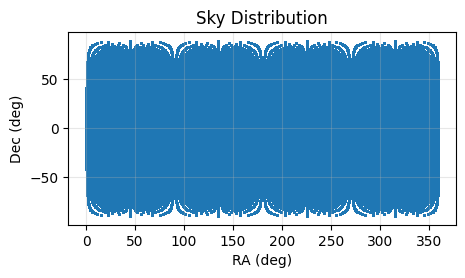

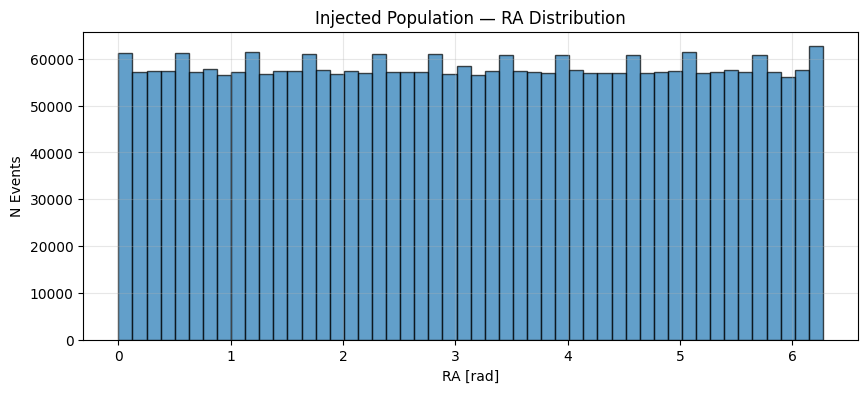

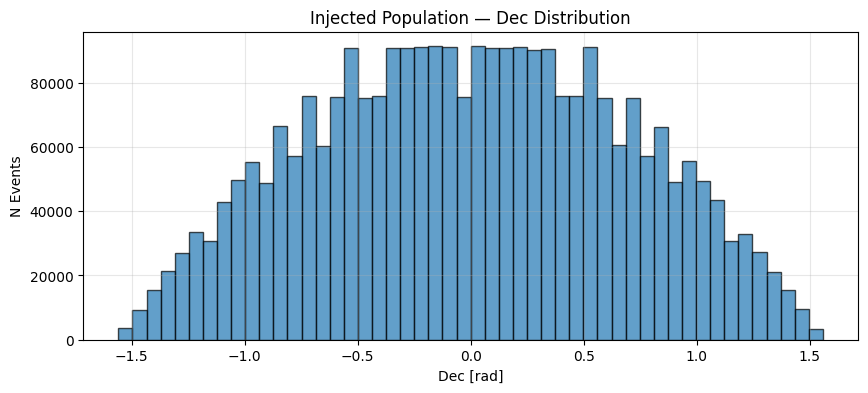

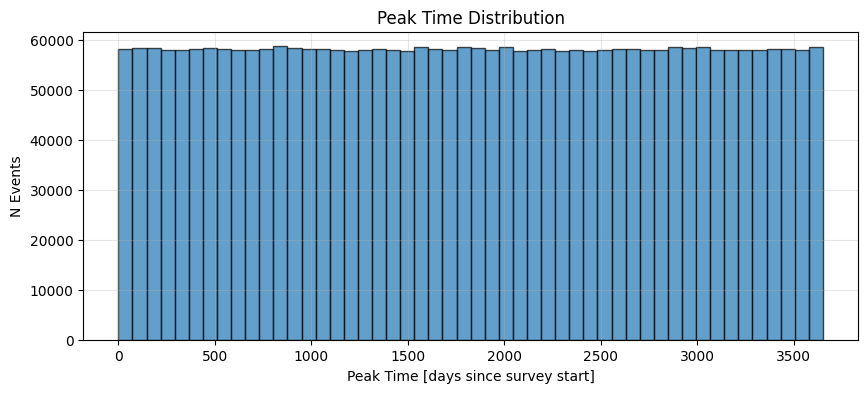

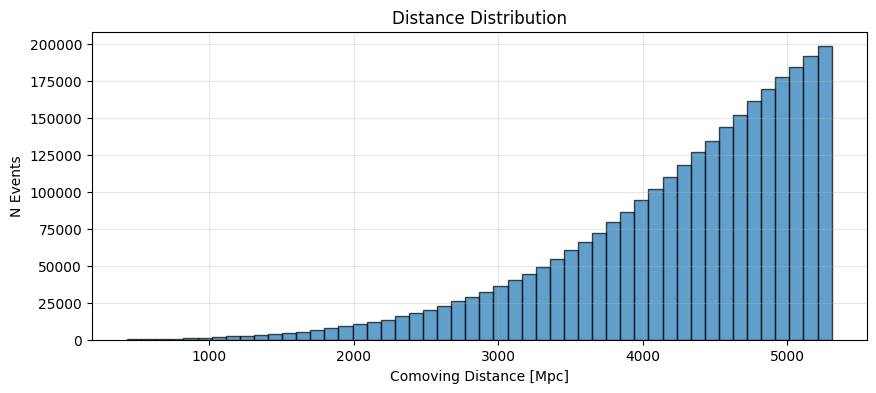

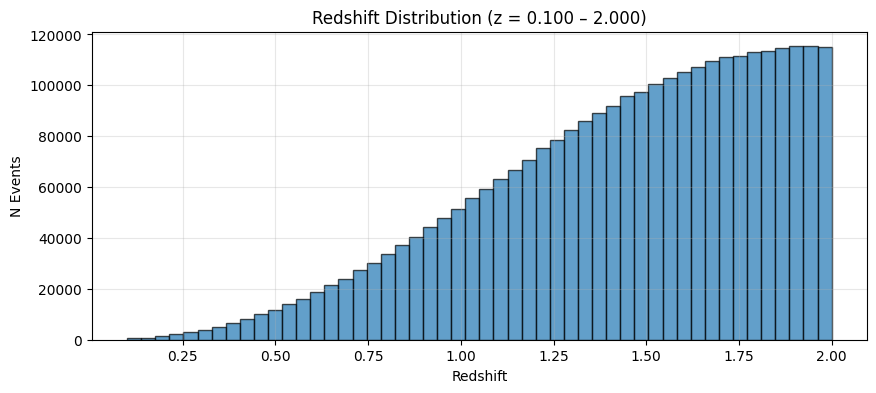

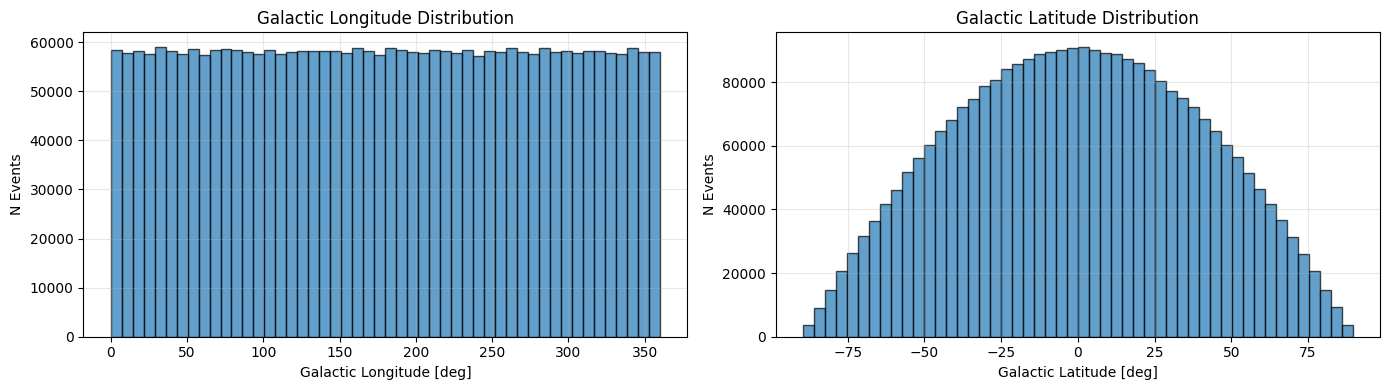

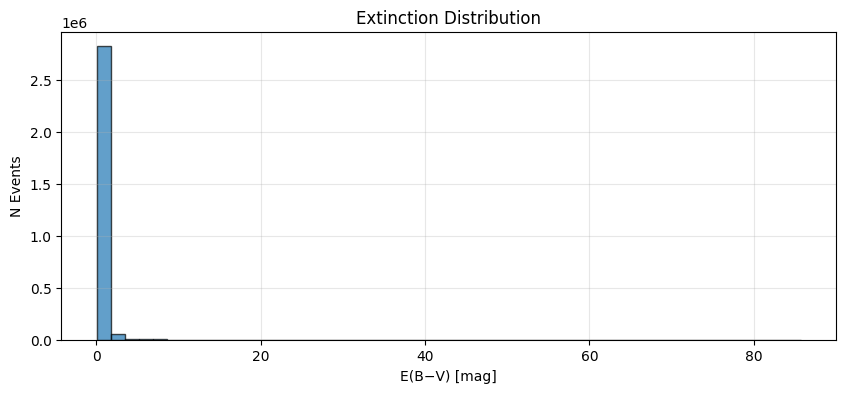

[INFO] Saved atomically to slsn_population_evolving.pkl
Saved SLSN population to slsn_population_evolving.pkl
Using provided survey duration: 10.00 years
✓ Saved to output/rate_vs_z_evolving.png


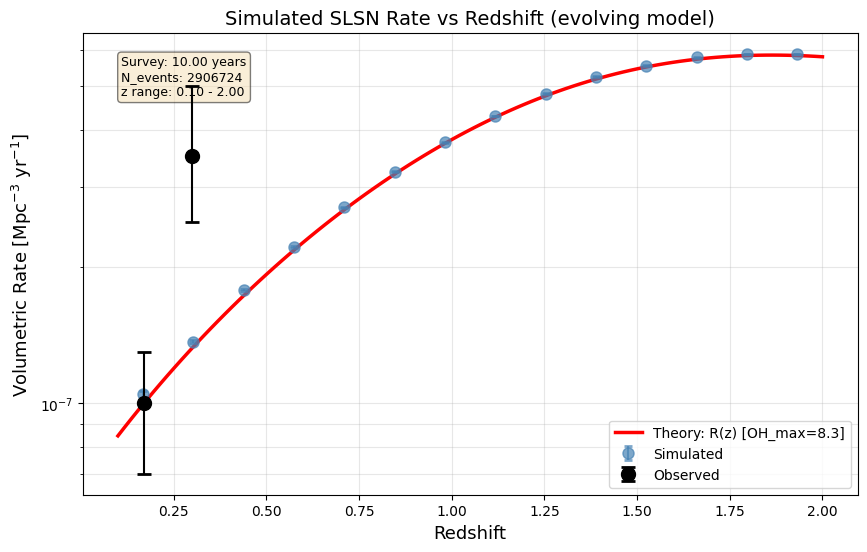

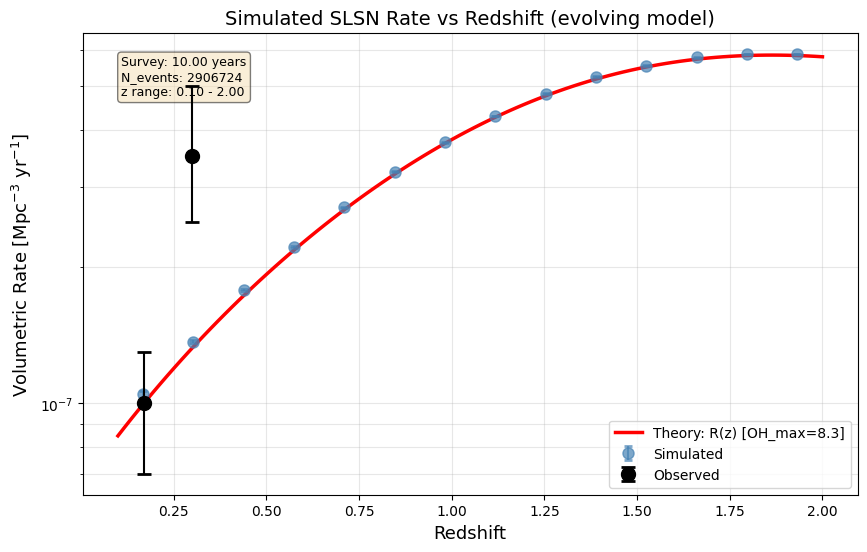

In [66]:
# Generate population with evolving rate
pop_evolving = generate_SLSN_PopSlicer_with_rate_evolution(
    templates,
    t_start=1,
    t_end=3652,  # 10 years
    z_min=0.1,
    z_max=2.0,
    rate_model='evolving',
    R_ref=1e-7,
    z_ref=0.17,
    OH_max=8.3,
    seed=42,
    save_to="slsn_population_evolving.pkl"
)

# Plot with CORRECT time duration
plot_population_rate_vs_redshift(
    pop_evolving,
    t_survey_days=3651,  # ← CRITICAL: Match t_end - t_start from generation
    rate_model='evolving',
    R_ref=1e-7,
    z_ref=0.17,
    OH_max=8.3,
    save_path="output/rate_vs_z_evolving.png"
)